In [2]:
import csv
from datetime import datetime
import numpy as np
import trompy as tp

def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']
    
    try:
        file = open(filename)
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []
    
    csvreader = csv.reader(file)
    next(csvreader)  # Skip header
    rows = []
    for row in csvreader:
        rows.append(row)

    # Check if rows are empty
    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []

    # Determine which format should be used
    try:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[0])
        date_format = formats[0]
    except ValueError:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[1])
        date_format = formats[1]

    timestamps = []
    for row in rows: 
        if row[7] == eventname:  # Check event column
            date_time_obj = datetime.strptime(row[0], date_format)
            timestamps.append(date_time_obj)

    if len(timestamps) == 0:
        print(f"No {eventname} events found in file: {filename}")
        return []

    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    refpoint = datetime.strptime(lightson, date_format)
    
    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        Deltatinhours = Deltatinseconds / 3600
        pellettimes.append(Deltatinhours)

    return pellettimes

def get_data_subset(dictionary, selectors, verbose=True):
    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in dictionary.keys():
            try:
                if output_dictionary[mouse_id][key] != value:
                    output_dictionary.pop(mouse_id)
            except KeyError: 
                pass

    if verbose:
        print("{} items in output dictionary".format(len(output_dictionary.keys())))
    
    return output_dictionary

def get_data_fields(dictionary, fields, selectors):
    output_list = []
    reduced_dictionary = get_data_subset(dictionary, selectors)
    
    if len(reduced_dictionary.keys()) > 0:
        for field in fields:
            output_sublist = []
            try:
                for key in reduced_dictionary.keys():
                    output_sublist.append(reduced_dictionary[key][field])
            except KeyError:
                print("{} is not a key in selected dictionary".format(field))
                return
            output_list.append(output_sublist)
    else:
        print("No data in fields in selected dictionary")

    if len(output_list) == 1:
        output_list = output_list[0]
        
    return output_list
# Function to get meal, snack, and mega meal metrics, including mega_meal_frequency and mega_meal_size
def get_meal_and_snack_metrics(pellettimes, meal_threshold=1/60):
    if not pellettimes:
        return (0, 0, 0, 0, 0, 0, 0, 0, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, 0, 0, 0, 0)

    IPIs = np.diff(np.array(pellettimes))
    meals = []
    snacks = []
    mega_meals = []
    current_event = [pellettimes[0]]

    # Hourly tracking for each day
    hourly_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_snacks_per_day = [[0]*24 for _ in range(7)]
    hourly_mega_meals_per_day = [[0]*24 for _ in range(7)]

    for i, ipi in enumerate(IPIs):
        if ipi <= meal_threshold:
            current_event.append(pellettimes[i + 1])
        else:
            if len(current_event) == 1:
                snacks.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:  # Make sure we are within the 7-day boundary
                    hourly_snacks_per_day[day_index][hour] += 1
            elif 2 <= len(current_event) <= 5:
                meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_meals_per_day[day_index][hour] += 1
            elif len(current_event) >= 6:
                mega_meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_mega_meals_per_day[day_index][hour] += 1
            current_event = [pellettimes[i + 1]]

    # Handle the last sequence
    if current_event:
        day_index = int(current_event[0] // 24)
        hour = int(current_event[0]) % 24
        if len(current_event) == 1:
            snacks.append(current_event)
            if day_index < 7:
                hourly_snacks_per_day[day_index][hour] += 1
        elif 2 <= len(current_event) <= 4:
            meals.append(current_event)
            if day_index < 7:
                hourly_meals_per_day[day_index][hour] += 1
        elif len(current_event) >= 5:
            mega_meals.append(current_event)
            if day_index < 7:
                hourly_mega_meals_per_day[day_index][hour] += 1

    nmeals = len(meals)
    nsnacks = len(snacks)
    n_mega_meals = len(mega_meals)  # Add the number of mega meals

    total_pellets = len(pellettimes)
    mealsize = sum(len(meal) for meal in meals) / nmeals if nmeals else 0
    snack_size = sum(len(snack) for snack in snacks) / nsnacks if nsnacks else 0
    total_observation_period = max(pellettimes) - min(pellettimes)
    meal_frequency = nmeals / total_observation_period if total_observation_period > 0 else 0
    snack_frequency = nsnacks / total_observation_period if total_observation_period > 0 else 0
    mega_meal_frequency = n_mega_meals / total_observation_period if total_observation_period > 0 else 0
    average_mega_meal_size = sum(len(meal) for meal in mega_meals) / n_mega_meals if n_mega_meals else 0

    return (mealsize, snack_size, nmeals, meal_frequency, nsnacks, snack_frequency, 
            mega_meal_frequency, average_mega_meal_size, hourly_meals_per_day, 
            hourly_snacks_per_day, hourly_mega_meals_per_day, meals, snacks, mega_meals, n_mega_meals)


# Function to get events (meals, snacks, mega meals) per day based on timestamps
def get_events_per_day(events, days=7):
    events_per_day = [0] * days  # Initialize with zeros for the duration of the phase
    for event_list in events:
        if len(event_list) > 0:
            event_day = int(event_list[0] // 24)
            if event_day < days:
                events_per_day[event_day] += 1
    return events_per_day

# Function to calculate pellets per day
def get_pellets_per_day(timestamps, days=7):
    pellets_per_day = [0] * days
    for day in range(days):
        pellets = [t for t in timestamps if (t > day * 24) and (t < (day + 1) * 24)]
        n_pellets = len(pellets)
        pellets_per_day[day] = n_pellets

    return pellets_per_day


# Function to calculate inter-pellet intervals (IPI)
def get_interpellet_intervals(pellettimes):
    IPIs = np.diff(pellettimes)
    return IPIs

# Function to calculate intermeal intervals (IMI)
def get_intermeal_interval(pellettimes, meal_threshold=1/60):
    IPIs = np.diff(pellettimes)
    IMIs = [x for x in IPIs if x > meal_threshold]
    average_IMI = np.mean(IMIs) if IMIs else 0  # Handle case with no IMIs
    return average_IMI

# Load the metafile and process the data
metafile = "..\\src\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(metafile, sheetname="METAFILE")

mice = {}
for row in rows:
    mouse_id = row[1]
    if mouse_id not in mice.keys():
        mice[mouse_id] = {}
        mice[mouse_id]["sex"] = row[4]
        mice[mouse_id]["order"] = row[5]

for key in mice.keys():
    for row in rows:
        if row[1] == key and row[3] == "FF":
            filename = "..\\src\\data\\{}".format(row[0])
            if row[2] == "GRAIN":
                mice[key]["grain_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "PR":
                mice[key]["pr_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "NR":
                mice[key]["nr_timestamps"] = get_FEDevents(filename, "Pellet")
            else:
                print(row[2], "is not a valid type of pellet for", key)

# Add meal, snack, mega meal metrics, and IMI, IPI calculations to the dictionary
for key in mice.keys():
    grain_timestamps = mice[key].get("grain_timestamps", [])
    pr_timestamps = mice[key].get("pr_timestamps", [])
    nr_timestamps = mice[key].get("nr_timestamps", [])

    # Get metrics for GRAIN, PR, and NR phases
    grain_metrics = get_meal_and_snack_metrics(grain_timestamps)
    pr_metrics = get_meal_and_snack_metrics(pr_timestamps)
    nr_metrics = get_meal_and_snack_metrics(nr_timestamps)

    # GRAIN phase
    (
        mice[key]["grain_meal_size"],
        mice[key]["grain_snack_size"],
        mice[key]["grain_number_of_meals"],
        mice[key]["grain_meal_frequency"],
        mice[key]["grain_number_of_snacks"],
        mice[key]["grain_snack_frequency"],
        mice[key]["grain_mega_meal_frequency"],
        mice[key]["grain_mega_meal_size"],
        mice[key]["grain_hourly_meals"],
        mice[key]["grain_hourly_snacks"],
        mice[key]["grain_hourly_mega_meals"],
        grain_meals,
        grain_snacks,
        grain_mega_meals,
        mice[key]["grain_number_of_mega_meals"]  # Store the number of mega meals
    ) = grain_metrics

    # PR phase
    (
        mice[key]["pr_meal_size"],
        mice[key]["pr_snack_size"],
        mice[key]["pr_number_of_meals"],
        mice[key]["pr_meal_frequency"],
        mice[key]["pr_number_of_snacks"],
        mice[key]["pr_snack_frequency"],
        mice[key]["pr_mega_meal_frequency"],
        mice[key]["pr_mega_meal_size"],
        mice[key]["pr_hourly_meals"],
        mice[key]["pr_hourly_snacks"],
        mice[key]["pr_hourly_mega_meals"],
        pr_meals,
        pr_snacks,
        pr_mega_meals,
        mice[key]["pr_number_of_mega_meals"]  # Store the number of mega meals
    ) = pr_metrics

    # NR phase
    (
        mice[key]["nr_meal_size"],
        mice[key]["nr_snack_size"],
        mice[key]["nr_number_of_meals"],
        mice[key]["nr_meal_frequency"],
        mice[key]["nr_number_of_snacks"],
        mice[key]["nr_snack_frequency"],
        mice[key]["nr_mega_meal_frequency"],
        mice[key]["nr_mega_meal_size"],
        mice[key]["nr_hourly_meals"],
        mice[key]["nr_hourly_snacks"],
        mice[key]["nr_hourly_mega_meals"],
        nr_meals,
        nr_snacks,
        nr_mega_meals,
        mice[key]["nr_number_of_mega_meals"]  # Store the number of mega meals
    ) = nr_metrics

    # Events per day and pellets per day (as previously done)
    mice[key]["grain_meals_per_day"] = get_events_per_day(grain_meals, days=3)
    mice[key]["pr_meals_per_day"] = get_events_per_day(pr_meals, days=7)
    mice[key]["nr_meals_per_day"] = get_events_per_day(nr_meals, days=7)

    mice[key]["grain_snacks_per_day"] = get_events_per_day(grain_snacks, days=3)
    mice[key]["pr_snacks_per_day"] = get_events_per_day(pr_snacks, days=7)
    mice[key]["nr_snacks_per_day"] = get_events_per_day(nr_snacks, days=7)

    mice[key]["grain_mega_meals_per_day"] = get_events_per_day(grain_mega_meals, days=3)
    mice[key]["pr_mega_meals_per_day"] = get_events_per_day(pr_mega_meals, days=7)
    mice[key]["nr_mega_meals_per_day"] = get_events_per_day(nr_mega_meals, days=7)

    mice[key]["grain_pellets_per_day"] = get_pellets_per_day(mice[key]["grain_timestamps"], days=3)
    mice[key]["pr_pellets_per_day"] = get_pellets_per_day(mice[key]["pr_timestamps"], days=7)
    mice[key]["nr_pellets_per_day"] = get_pellets_per_day(mice[key]["nr_timestamps"], days=7)


# Now combine events and pellets per day for the entire 17-day time course (as before)
for key in mice.keys():
    # Combine pellets per day
    mice[key]["all_pellets_per_day"] = (
        mice[key].get("grain_pellets_per_day", [0] * 3) +
        mice[key].get("pr_pellets_per_day", [0] * 7) +
        mice[key].get("nr_pellets_per_day", [0] * 7)
    )

    # Combine meals per day
    mice[key]["all_meals_per_day"] = (
        mice[key].get("grain_meals_per_day", [0] * 3) +
        mice[key].get("pr_meals_per_day", [0] * 7) +
        mice[key].get("nr_meals_per_day", [0] * 7)
    )

    # Combine snacks per day
    mice[key]["all_snacks_per_day"] = (
        mice[key].get("grain_snacks_per_day", [0] * 3) +
        mice[key].get("pr_snacks_per_day", [0] * 7) +
        mice[key].get("nr_snacks_per_day", [0] * 7)
    )

    # Combine mega meals per day
    mice[key]["all_mega_meals_per_day"] = (
        mice[key].get("grain_mega_meals_per_day", [0] * 3) +
        mice[key].get("pr_mega_meals_per_day", [0] * 7) +
        mice[key].get("nr_mega_meals_per_day", [0] * 7)
    )

# Output the results to check the data structure
for key, value in mice.items():
    print(f"Mouse {key}:")
    print("  Pellets per day:", mice[key]["all_pellets_per_day"])
    print("  Meals per day:", mice[key]["all_meals_per_day"])
    print("  Snacks per day:", mice[key]["all_snacks_per_day"])
    print("  Mega Meals per hour:", mice[key]["nr_hourly_mega_meals"])
    print("  Mega Meals Frequency:", mice[key]["nr_mega_meal_frequency"])
    print("  Mega Meals Size:", mice[key]["nr_mega_meal_size"])

Mouse FEDXA01:
  Pellets per day: [340, 271, 224, 161, 155, 176, 184, 215, 231, 240, 246, 234, 222, 211, 241, 223, 219]
  Meals per day: [47, 30, 28, 37, 33, 36, 27, 30, 34, 25, 14, 24, 24, 21, 20, 11, 11]
  Snacks per day: [30, 18, 25, 32, 44, 52, 62, 28, 25, 13, 13, 14, 14, 19, 18, 12, 13]
  Mega Meals per hour: [[0, 0, 0, 2, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 2, 3, 2, 1, 0, 0, 1, 1, 1], [0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 2, 2, 2, 1, 2, 0, 0, 0], [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1], [0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 2, 2, 0, 1, 1, 1, 0], [1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 2, 3, 1, 0, 1, 0, 0, 1], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 1, 0, 2], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 2, 2, 2, 1, 1, 1, 1, 1, 2]]
  Mega Meals Frequency: 0.7914710335259267
  Mega Meals Size: 7.916666666666667
Mouse FEDXA02:
  Pellets per day: [304, 214, 194, 154, 153, 204, 211, 203, 226, 214, 

In [3]:
# Selectors for grouping mice data
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"}


11 items in output dictionary
12 items in output dictionary


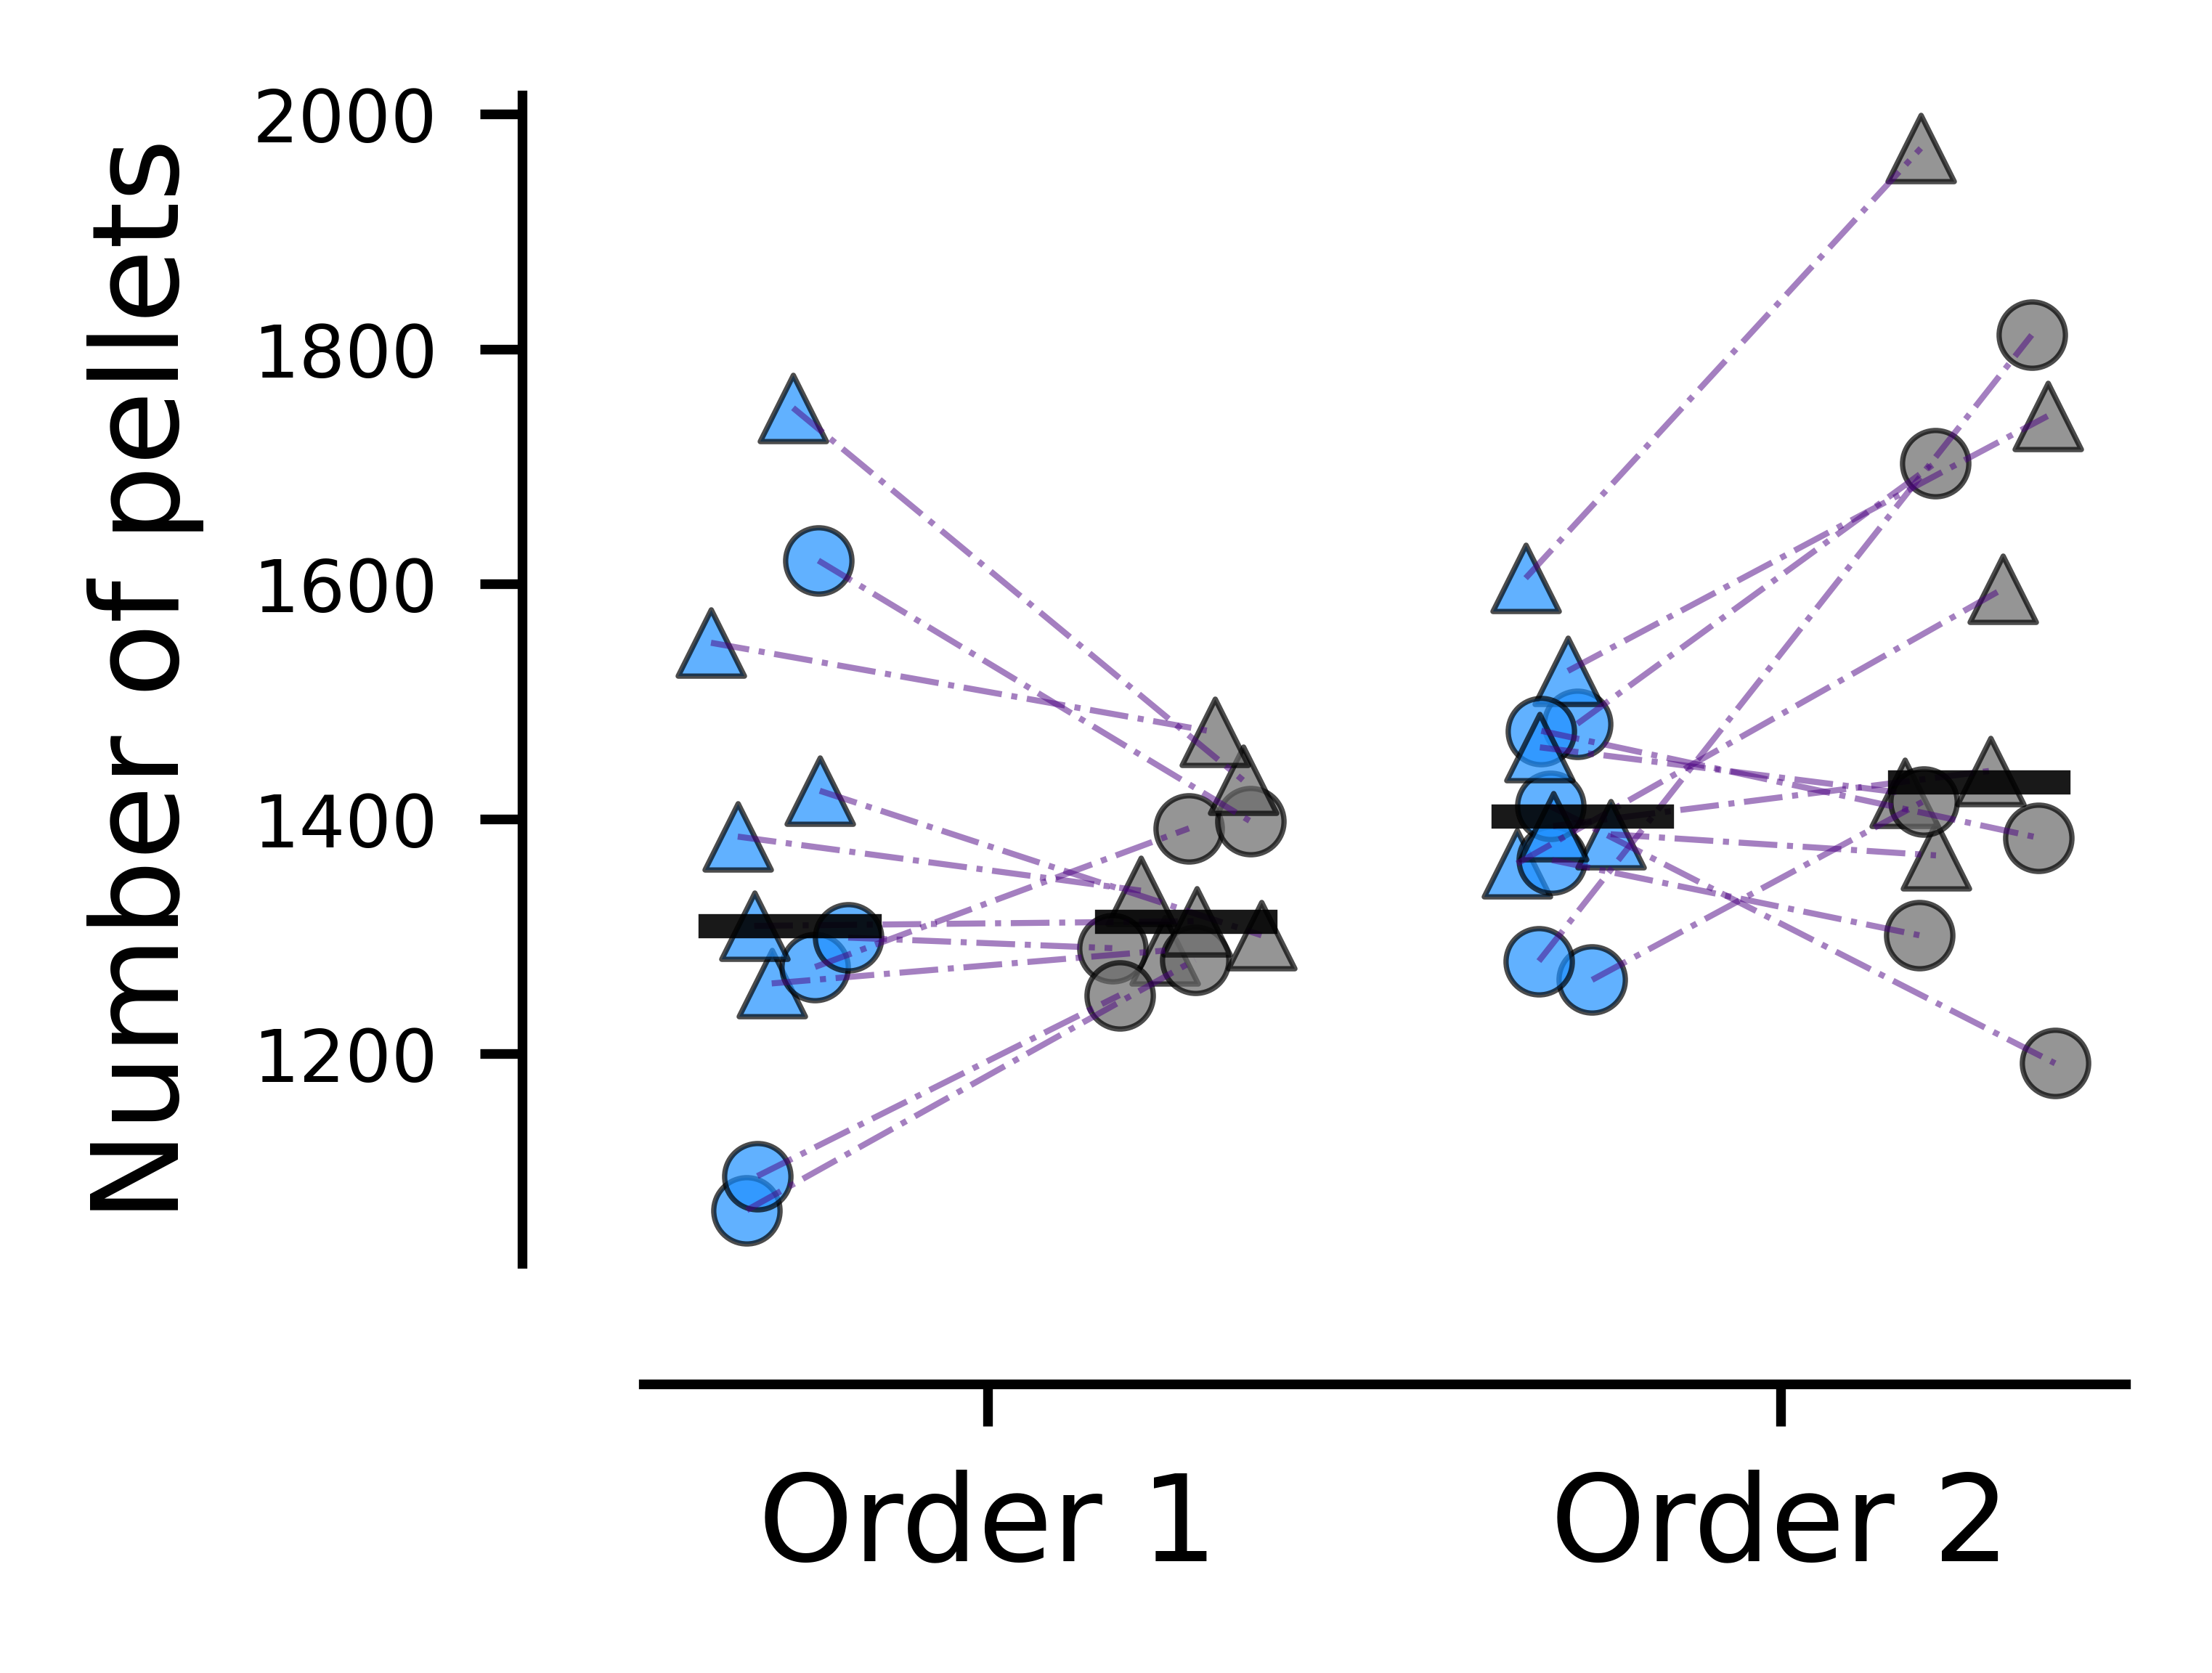

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Combine male and female data for PR and NR phases within each order
nrpr_order1_data = get_data_fields(mice, ["pr_pellets_per_day", "nr_pellets_per_day"], {"order": 1})
prnr_order2_data = get_data_fields(mice, ["pr_pellets_per_day", "nr_pellets_per_day"], {"order": 2})

# Sum pellets per day for each order and phase
nrpr_order1_pr_pellets = [sum(pellets) for pellets in nrpr_order1_data[0]]
nrpr_order1_nr_pellets = [sum(pellets) for pellets in nrpr_order1_data[1]]
prnr_order2_pr_pellets = [sum(pellets) for pellets in prnr_order2_data[0]]
prnr_order2_nr_pellets = [sum(pellets) for pellets in prnr_order2_data[1]]

# Prepare data for plotting
data = [nrpr_order1_pr_pellets, nrpr_order1_nr_pellets, prnr_order2_pr_pellets, prnr_order2_nr_pellets]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]

colors = {"PR": "dodgerblue", "NR": "dimgray"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Position for minimal gap between groups

# Create a figure and axis
fig, ax = plt.subplots(figsize=(2.5, 1.88), dpi=1200)
jitter_strength = 0.02

# Plot combined data points with gender-specific markers
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for each order
    nr_data = data[i * 2 + 1]  # NR data for each order

    # Apply jitter to x-positions and assign markers based on sex
    pr_x = [group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in pr_data]
    nr_x = [group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in nr_data]
    
    # Draw line connecting PR and NR for each combined data point
    for j in range(len(pr_data)):
        ax.plot([pr_x[j], nr_x[j]], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot individual data points with markers for gender (combined data)
        marker = '^' if j % 2 == 0 else 'o'  # Alternating marker for visibility in combined data
        sns.scatterplot(x=[pr_x[j]], y=[pr_data[j]], color=colors["PR"], marker=marker, s=30, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x[j]], y=[nr_data[j]], color=colors["NR"], marker=marker, s=30, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='black', linewidth=2, alpha=0.9)

# # Customize legend with combined markers
# custom_lines = [
#     Line2D([0], [0], marker='^', color='black',  linestyle='', markersize=4, label='Female', fillstyle='none'),
#     Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
# ]
# plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(0.05, 1.01), frameon=False, fontsize=4)





# # Add text labels for PR and NR
# plt.text(0.1,0.76, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=4)
# plt.text(0.1, 0.81, '20% casein', color='dimgray', transform=ax.transAxes, fontsize=4)

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=10)
plt.yticks(fontsize=6)
plt.xlabel("")
plt.ylabel("Number of pellets",fontsize=10)
ax.tick_params(axis='y', labelsize=6) 
ax.tick_params(axis='x', labelsize=10) 
sns.despine()

plt.tight_layout()
offset = 10  # points
ax.spines['bottom'].set_position(('outward', offset))
ax.spines['left'].set_position(('outward', offset))
plt.show()

# Save the figure
fig.savefig("../plots/Fig.2A.pdf")


11 items in output dictionary
12 items in output dictionary


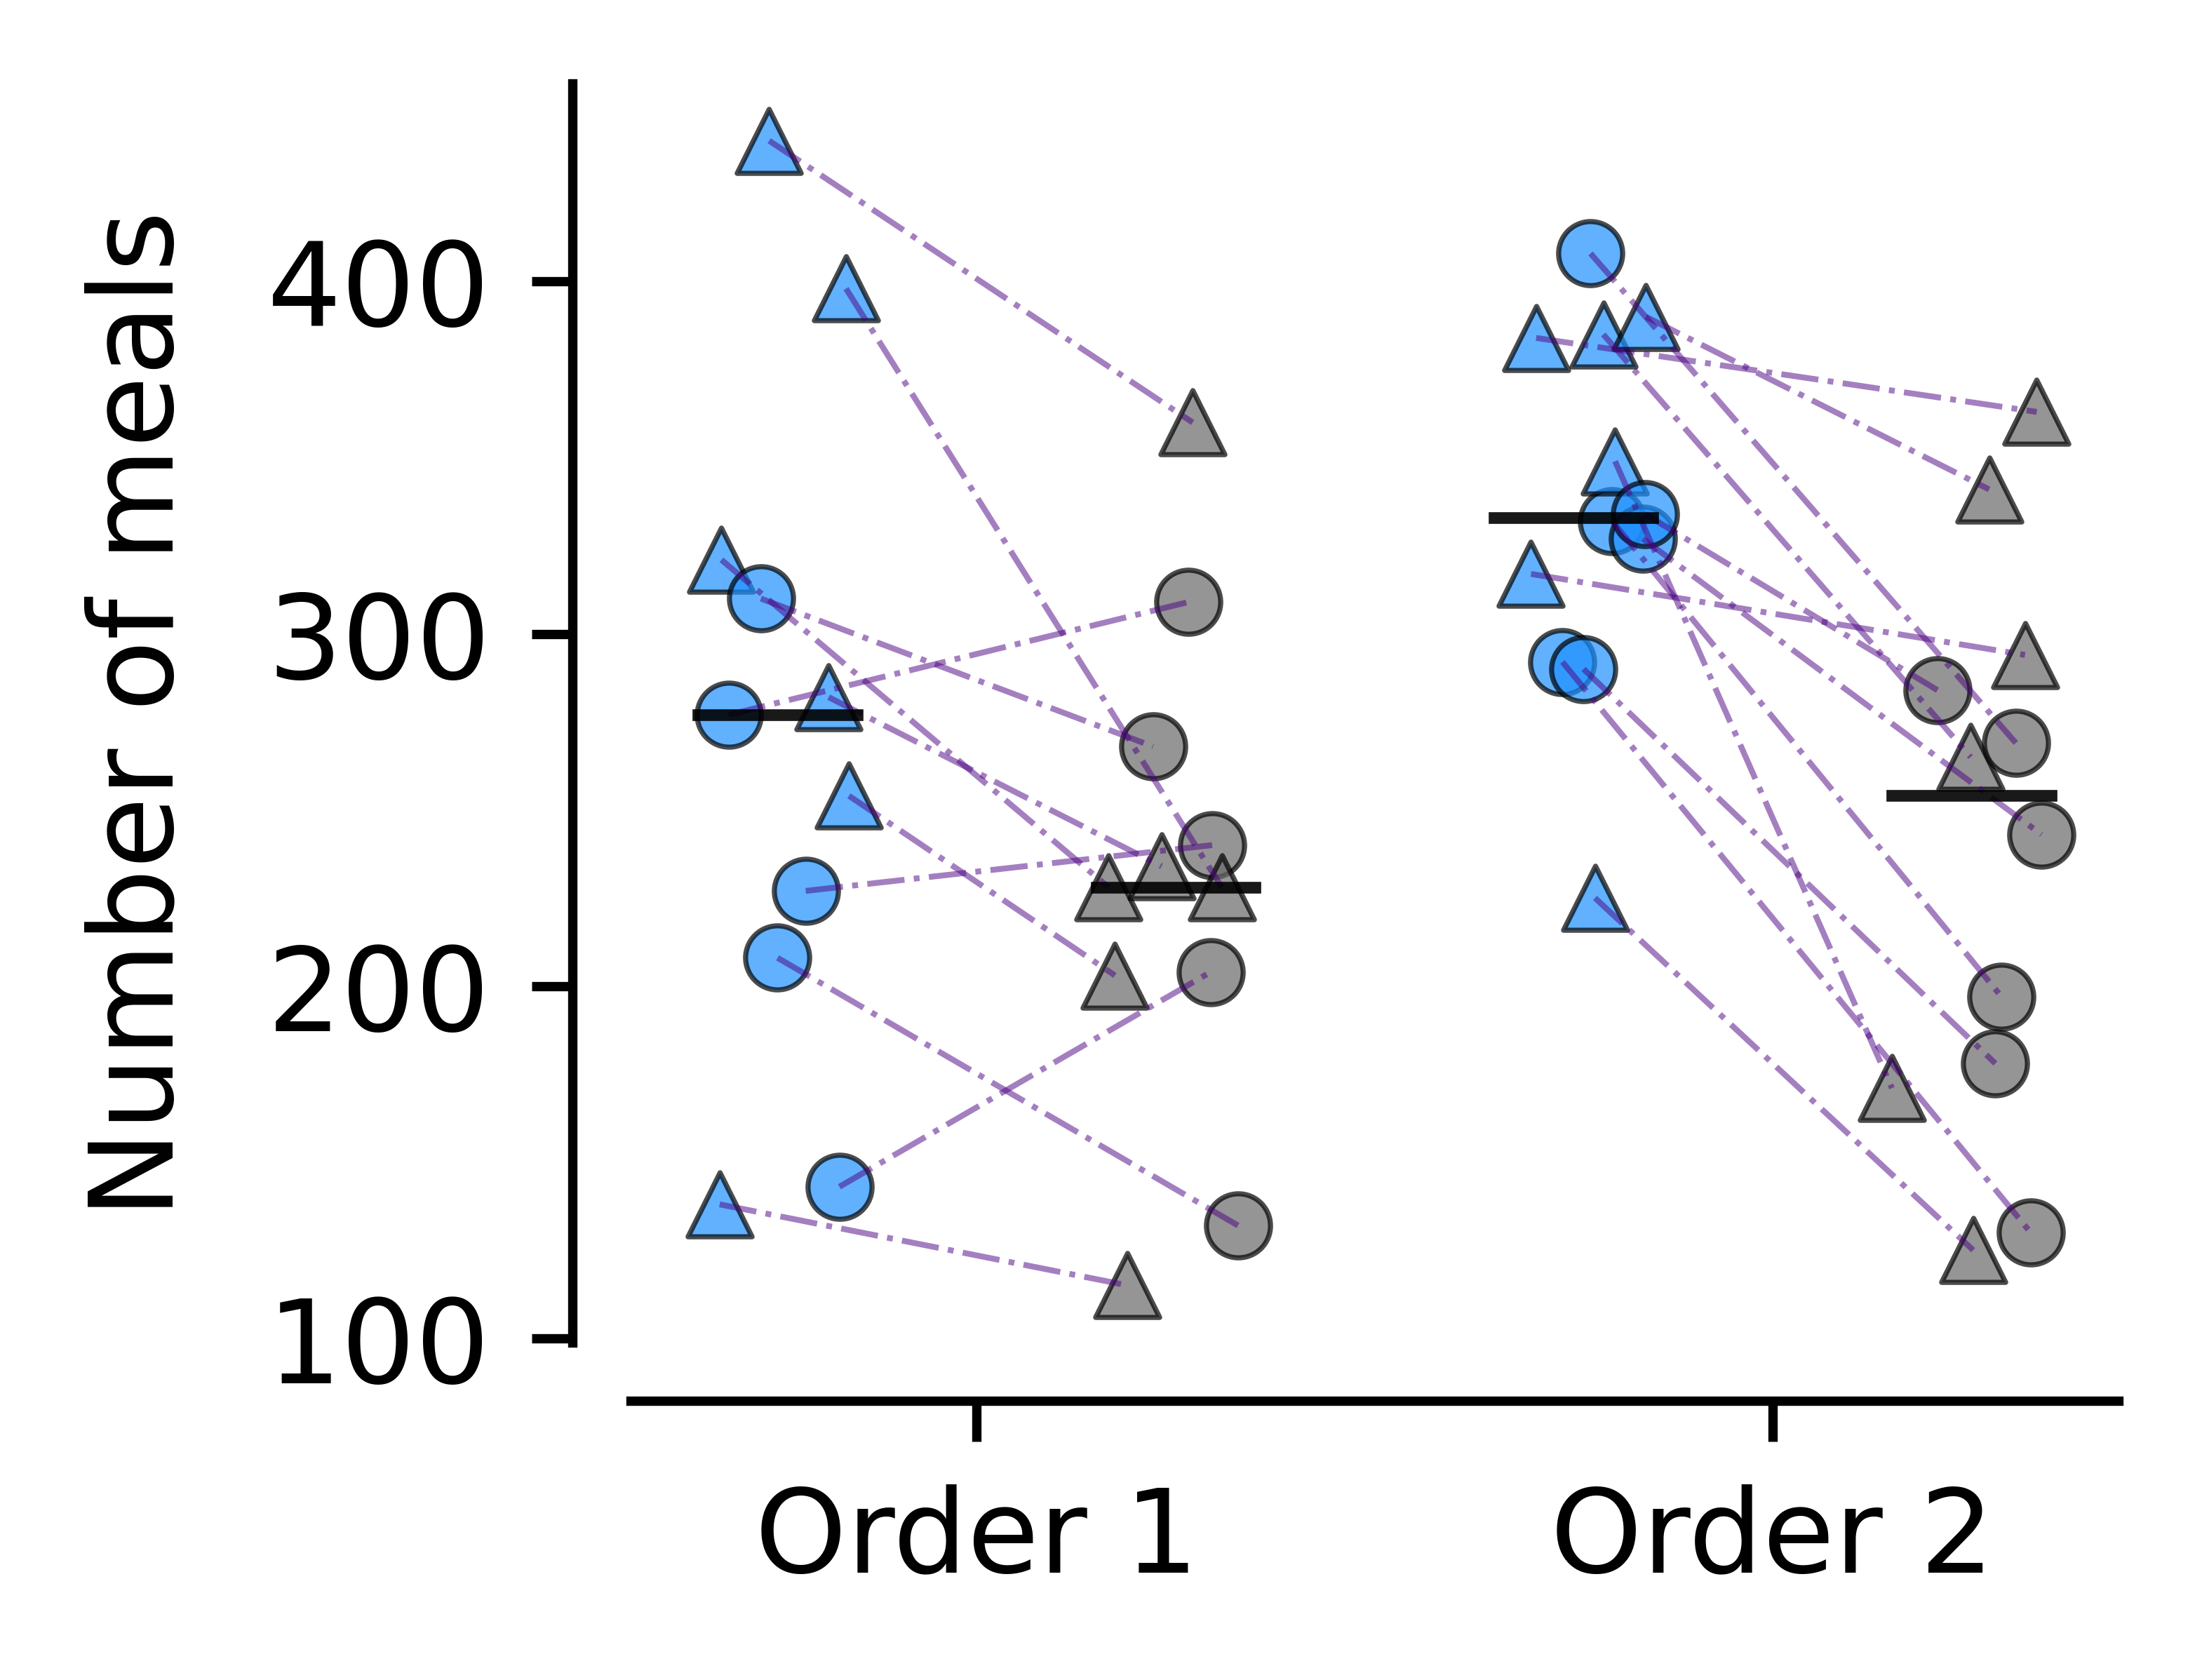

In [8]:

# Extract combined meal data for PR and NR phases, separated by order
nrpr_meals = get_data_fields(mice, ["pr_number_of_meals", "nr_number_of_meals"], {"order": 1})
prnr_meals = get_data_fields(mice, ["pr_number_of_meals", "nr_number_of_meals"], {"order": 2})

# Prepare data for plotting
data = [nrpr_meals[0], nrpr_meals[1], prnr_meals[0], prnr_meals[1]]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
offset = {"PR": -0.05, "NR": 0.05}       # jittered x-offset per diet
group_positions = {"Order 1": 0, "Order 2": 0.2}

# --- Figure (constrained layout) ---
fig, ax = plt.subplots(figsize=(2.5, 1.88), dpi=1200, constrained_layout=True)
jitter_strength = 0.02

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]        # PR data
    nr_data = data[i * 2 + 1]    # NR data

    for j in range(len(pr_data)):
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)

        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]],
                color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        marker = '^' if j % 2 == 0 else 'o'  # triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker,
                        s=30, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker,
                        s=30, alpha=0.7, edgecolor="black")

# Add median lines
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value],
                color='k', linewidth=1, alpha=0.9)

# # Legend for sex markers
# custom_lines = [
#     Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
#     Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
# ]
# ax.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 0.9),
#           frameon=False, fontsize=4)

# # Text-only colour labels for diets
# ax.text(1.05, 0.65, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=4)
# ax.text(1.05, 0.70, '20% casein', color='dimgray',   transform=ax.transAxes, fontsize=4)

# Axes formatting
ax.set_xticks([group_positions["Order 1"], group_positions["Order 2"]])
ax.set_xticklabels(["Order 1", "Order 2"], fontsize=10)
ax.set_xlabel("")
ax.set_ylabel("Number of meals", fontsize=10, labelpad=6)   # labelpad helps a touch
sns.despine()


spine_offset = 5  # points
ax.spines['bottom'].set_position(('outward', spine_offset))
ax.spines['left'].set_position(('outward', spine_offset))


fig.canvas.draw()  # ensures tight bbox accounts for everything
fig.savefig("../plots/Fig.5A.pdf",
            bbox_inches='tight', pad_inches=0.02)
plt.show()  


11 items in output dictionary
12 items in output dictionary


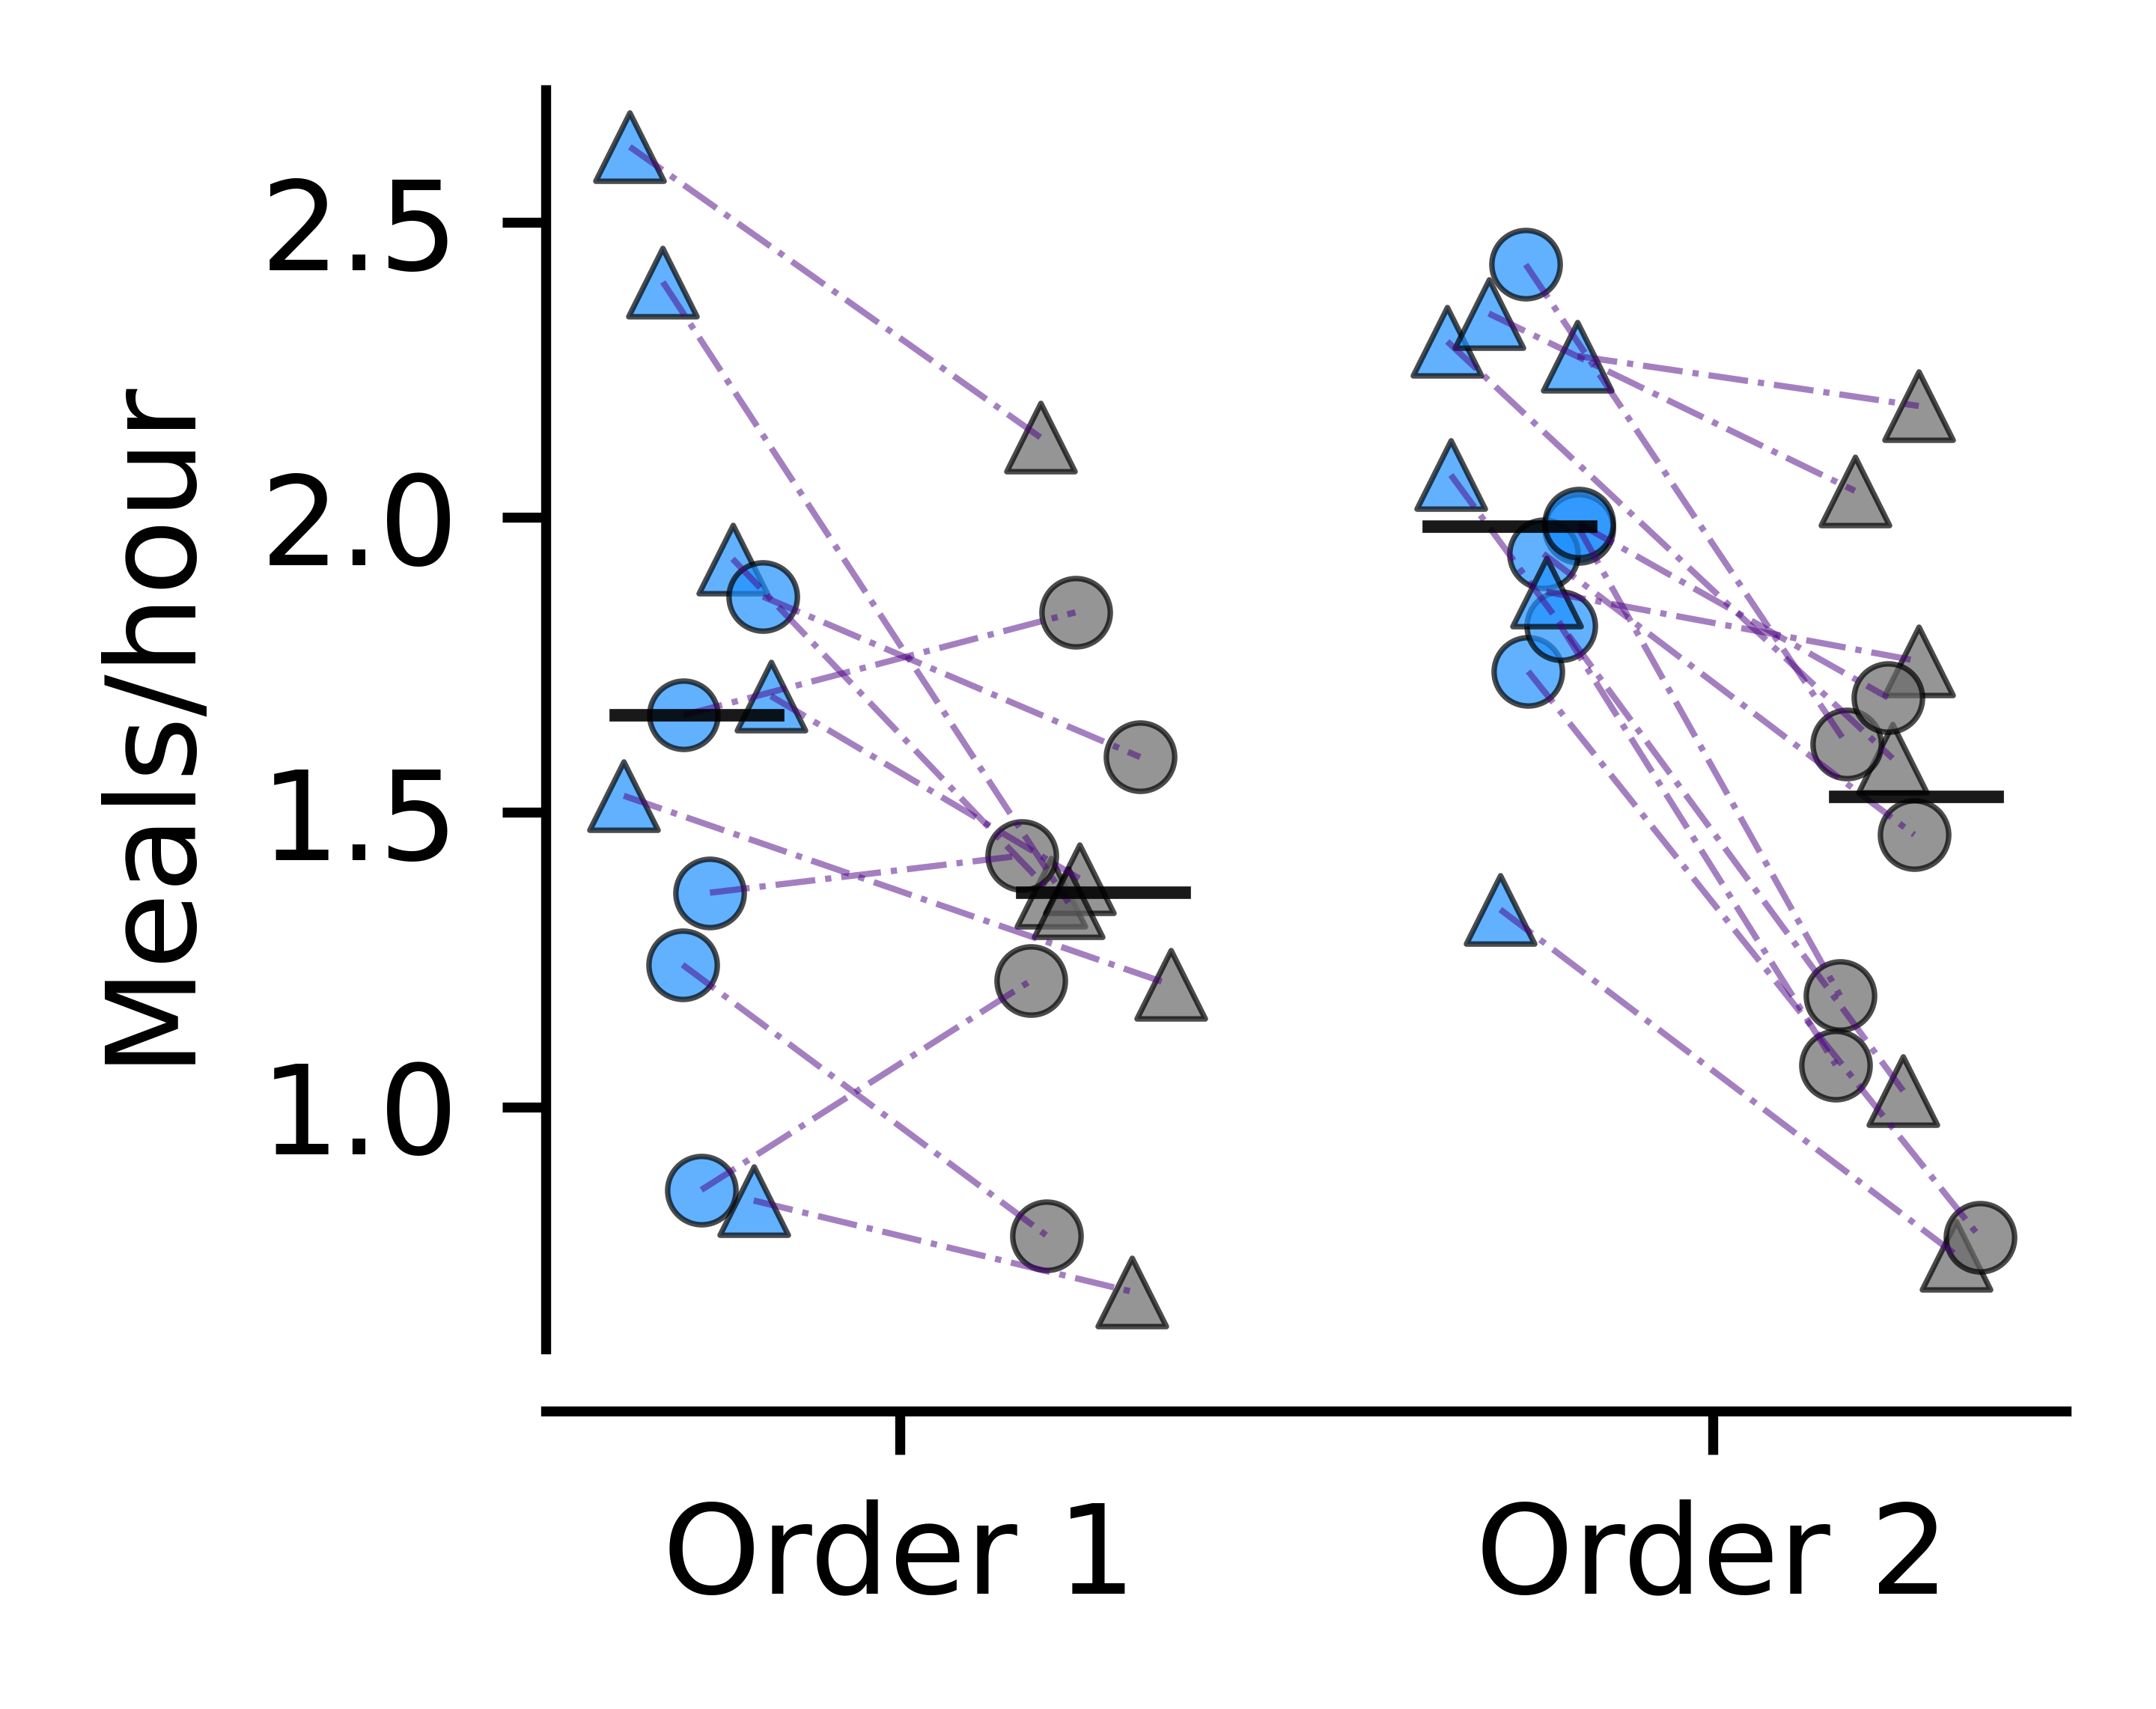

In [9]:
# Extract combined meal frequency data for PR and NR phases, separated by order
nrpr_frequency = get_data_fields(mice, ["pr_meal_frequency", "nr_meal_frequency"], {"order": 1})
prnr_frequency = get_data_fields(mice, ["pr_meal_frequency", "nr_meal_frequency"], {"order": 2})

# Prepare data for plotting
data = [nrpr_frequency[0], nrpr_frequency[1], prnr_frequency[0], prnr_frequency[1]]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Positions for minimal gap between groups

# Create a figure and axis
fig, ax = plt.subplots(figsize=(2.5, 1.88), dpi=1200)
jitter_strength = 0.02

# Plot data points and lines between PR and NR data
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for Order 1 or Order 2
    nr_data = data[i * 2 + 1]  # NR data for Order 1 or Order 2

    for j in range(len(pr_data)):
        # Apply jitter to x-positions
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Plot line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot data points with gender-specific markers
        marker = '^' if j % 2 == 0 else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=30, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=30, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1, alpha=0.9)

# # Customize legend with no frame and no title
# custom_lines = [
#     Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
#     Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
# ]
# plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 0.9), frameon=False, fontsize=4)

# # Add combined colored text for PR and NR next to the legend
# plt.text(1.05, 0.65, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=4)
# plt.text(1.05, 0.70, '20% casein', color='dimgray', transform=ax.transAxes, fontsize=4)

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=6)
plt.yticks(fontsize=10)
plt.xlabel("")
plt.ylabel("Meals/hour", fontsize=10)
sns.despine()
plt.tight_layout()
offset = 5  # points
ax.spines['bottom'].set_position(('outward', offset))
plt.show()

# Save the figure if needed
fig.savefig("../plots/Fig.5C.pdf",
            bbox_inches='tight', pad_inches=0.02)


11 items in output dictionary
12 items in output dictionary


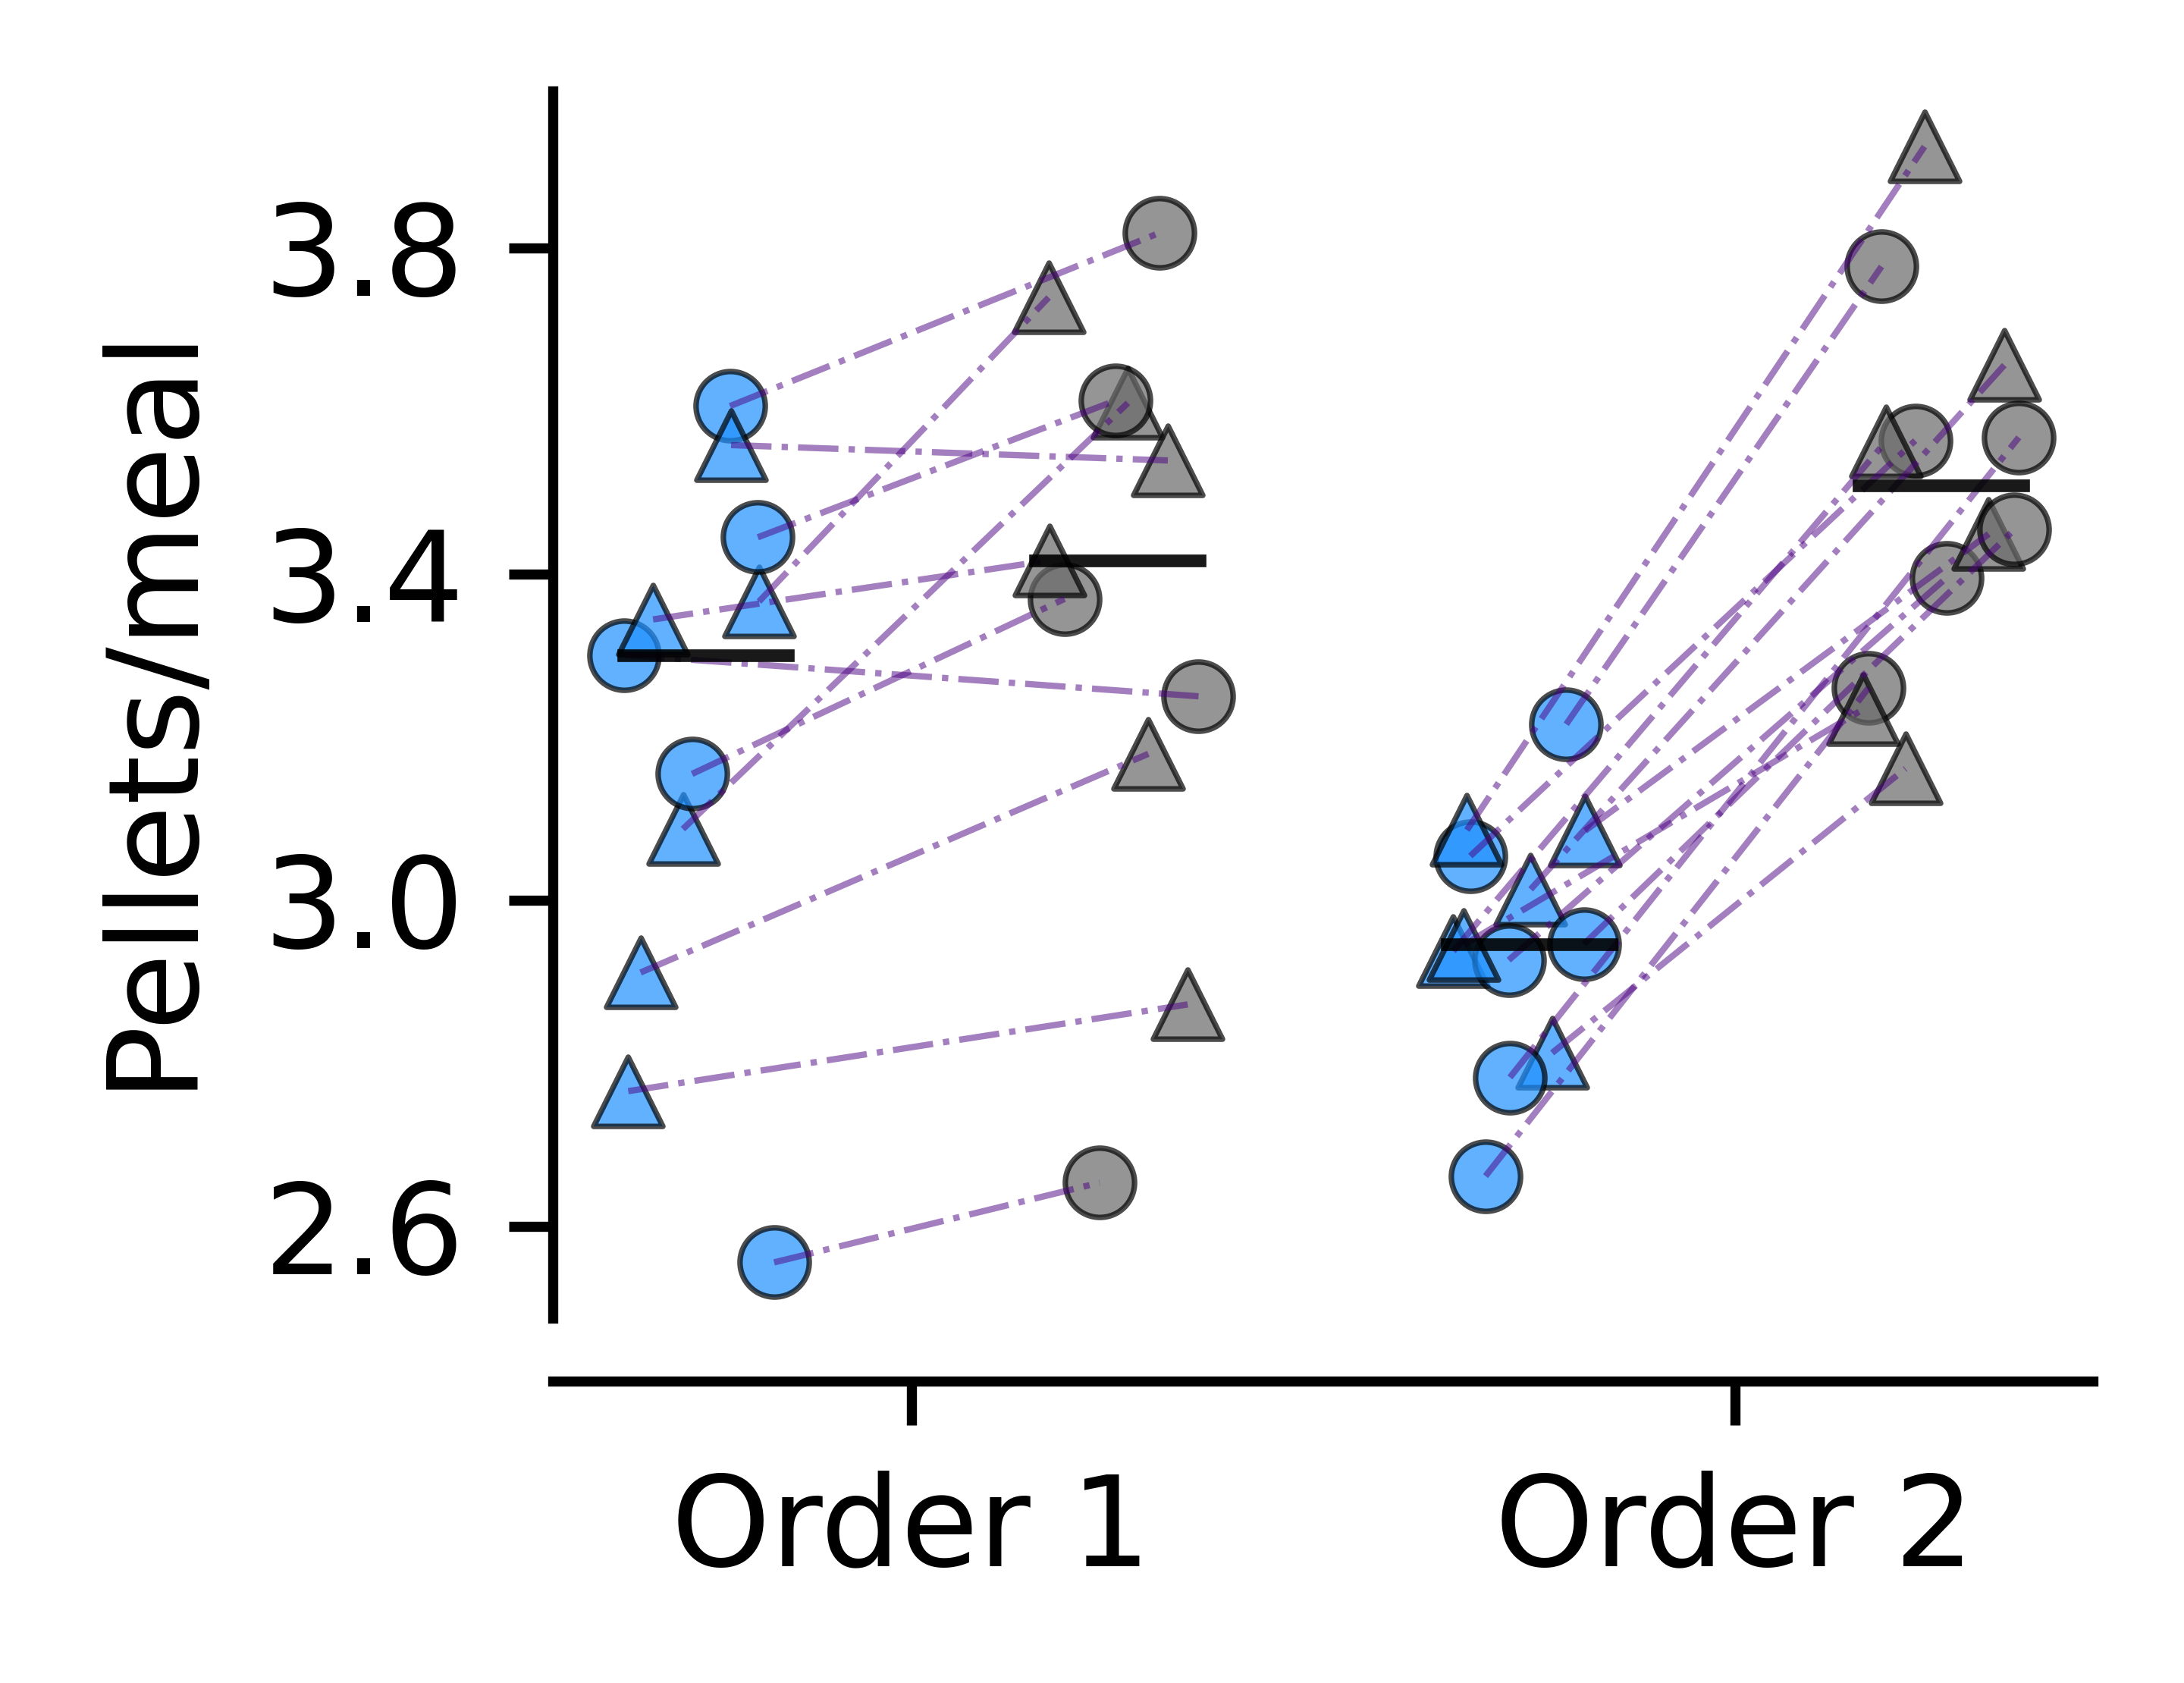

In [ ]:
# Extract combined meal size data for PR and NR phases, separated by order
nrpr_size = get_data_fields(mice, ["pr_meal_size", "nr_meal_size"], {"order": 1})
prnr_size = get_data_fields(mice, ["pr_meal_size", "nr_meal_size"], {"order": 2})

# Prepare data for plotting
data = [nrpr_size[0], nrpr_size[1], prnr_size[0], prnr_size[1]]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  #  minimal gap

# Create a figure and axis
fig, ax = plt.subplots(figsize=(2.5, 1.88), dpi=1200)
jitter_strength = 0.02

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for Order 1 or Order 2
    nr_data = data[i * 2 + 1]  # NR data for Order 1 or Order 2

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot individual data points with gender-specific markers
        marker = '^' if j % 2 == 0 else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=30, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=30, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1, alpha=0.9)

# # Customize legend with no frame and no title
# custom_lines = [
#     Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
#     Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
# ]
# plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 0.9), frameon=False, fontsize=4)

# # Add combined colored text for PR and NR next to the legend
# plt.text(1.05, 0.65, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=4)
# plt.text(1.05, 0.70, '20% casein', color='dimgray', transform=ax.transAxes, fontsize=4)

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]], ["Order 1", "Order 2"], fontsize=10)
plt.yticks(np.arange(2.6, 4, 0.4), fontsize=10)
plt.xlabel("")
plt.ylabel("Pellets/meal", fontsize=10)
sns.despine()
plt.tight_layout()
offset = 5  # points
ax.spines['bottom'].set_position(('outward', offset))
plt.show()

fig.savefig("../plots/Fig.5E.pdf",
            bbox_inches='tight', pad_inches=0.02)


11 items in output dictionary
12 items in output dictionary


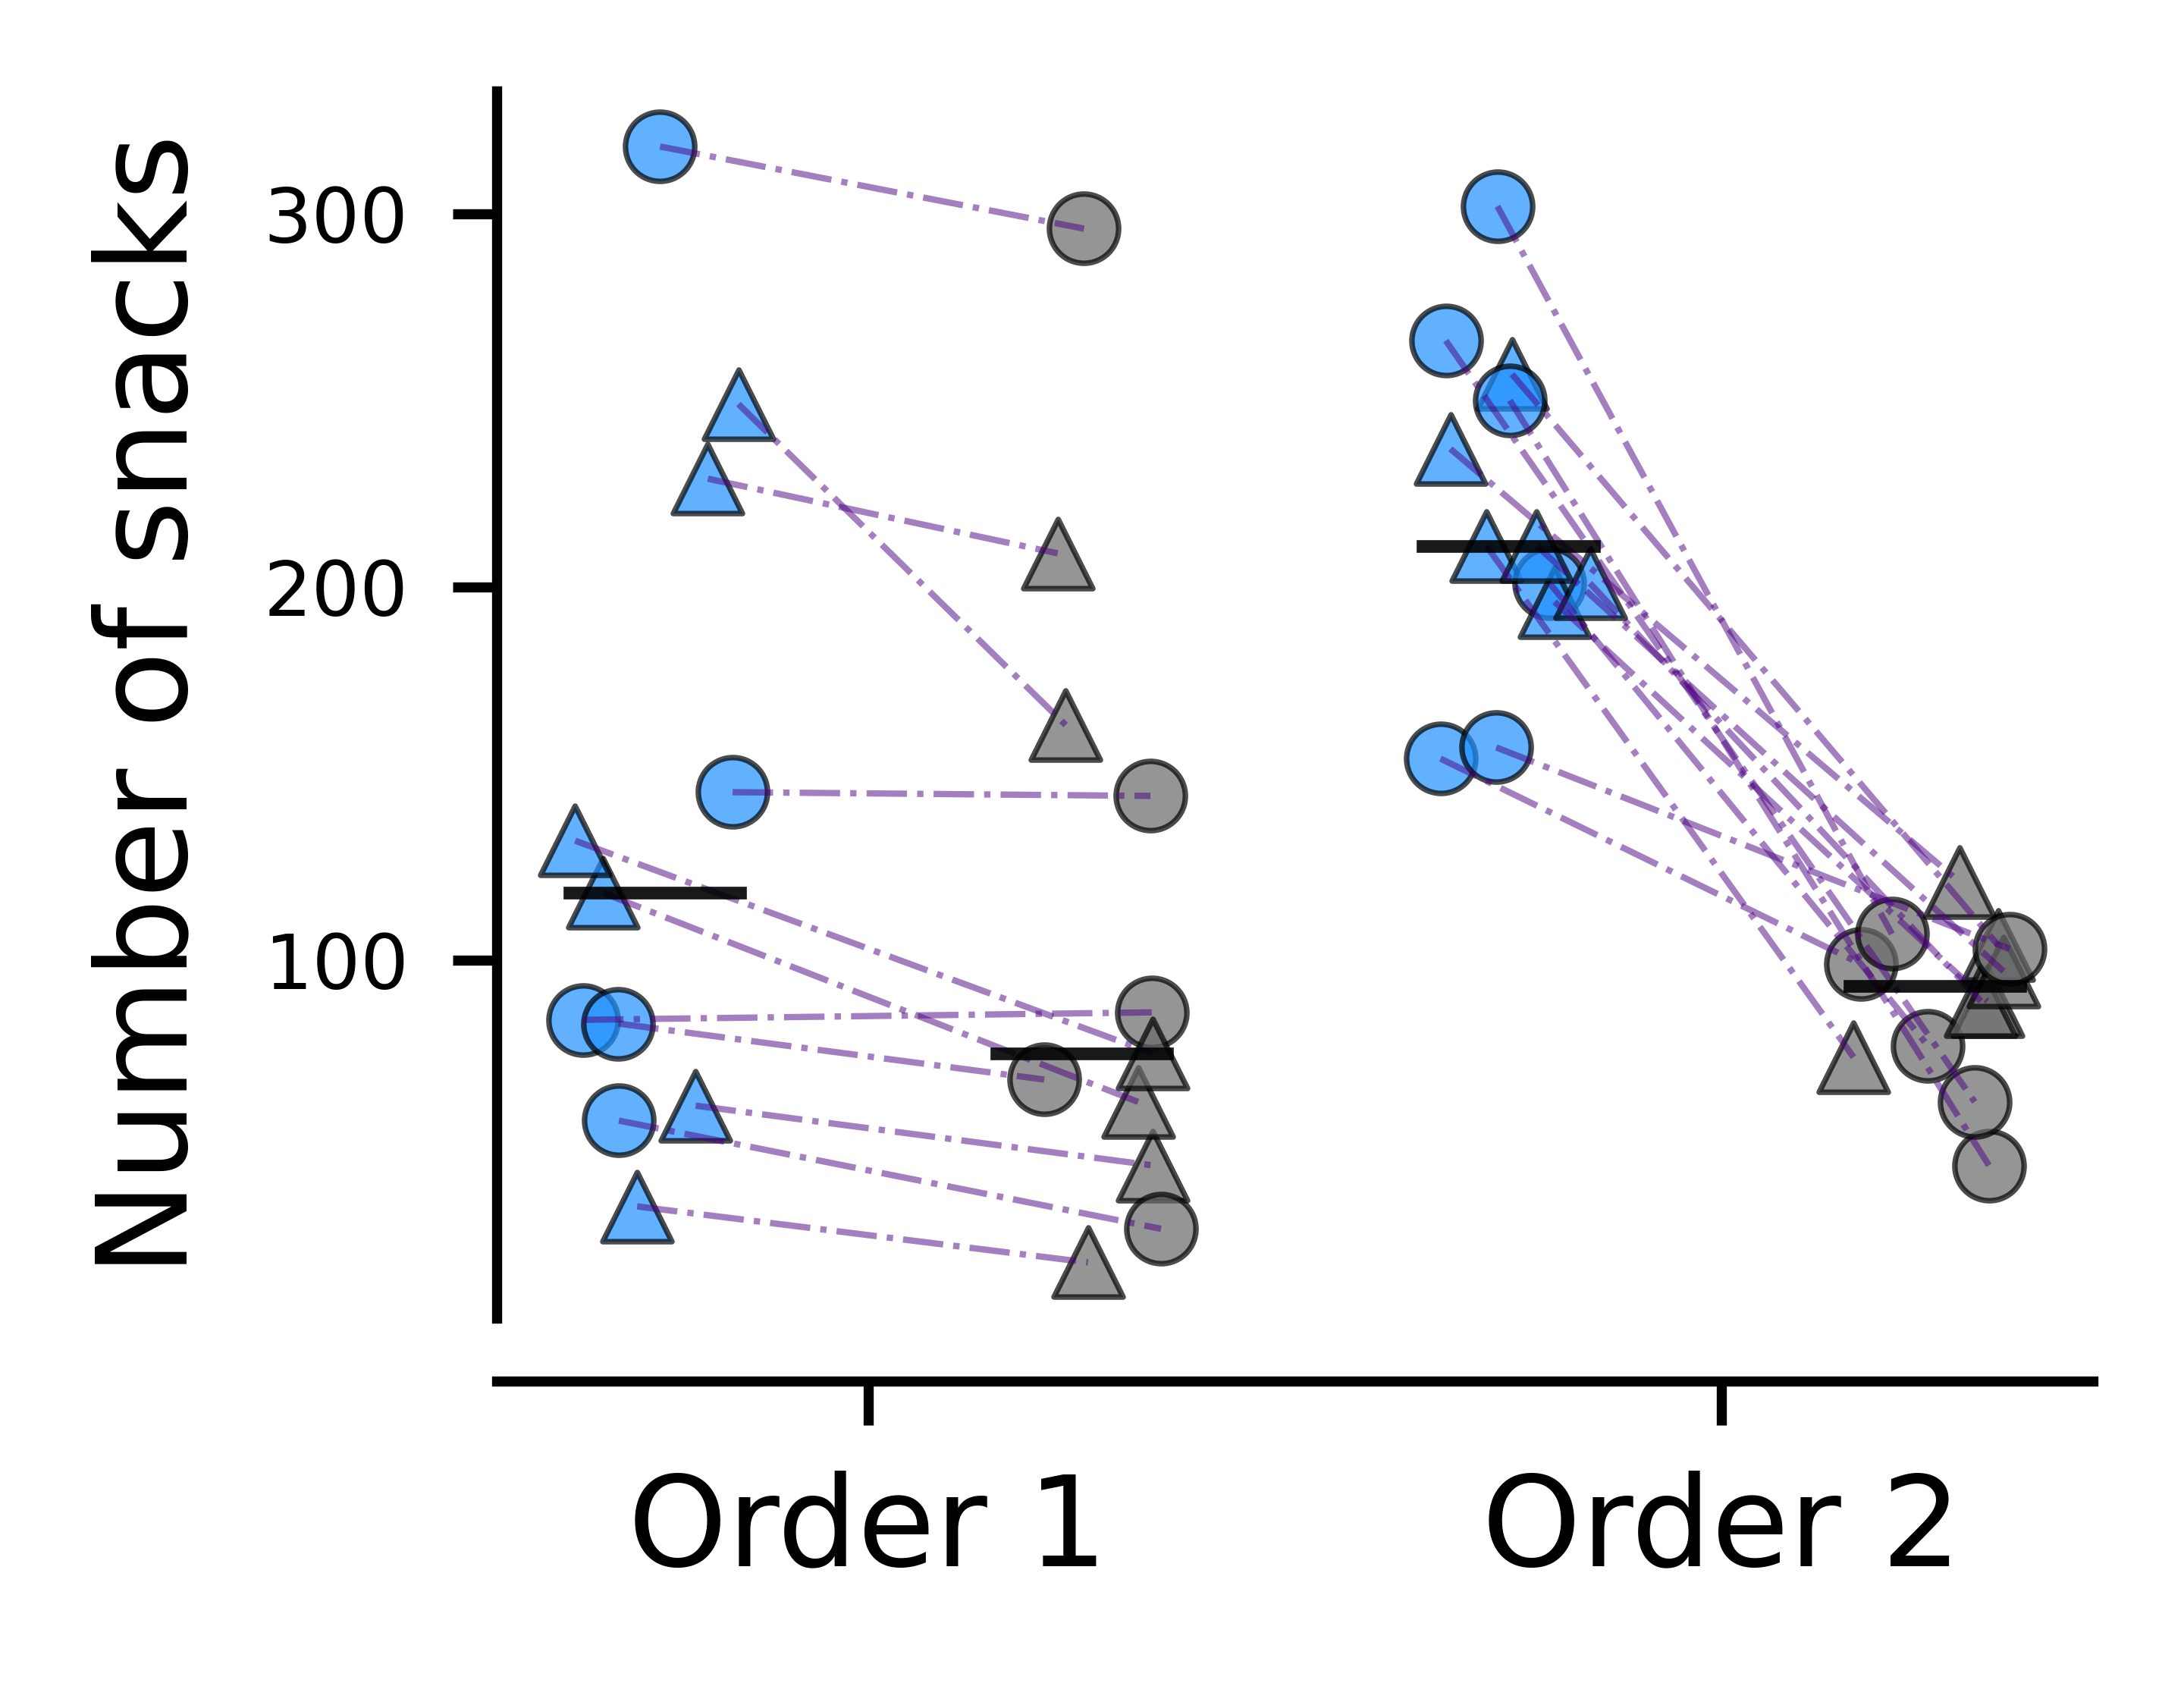

In [11]:

# Extract combined snack count data for PR and NR phases, separated by order
nrpr_snacks = get_data_fields(mice, ["pr_number_of_snacks", "nr_number_of_snacks"], {"order": 1})
prnr_snacks = get_data_fields(mice, ["pr_number_of_snacks", "nr_number_of_snacks"], {"order": 2})

# Prepare data for plotting
data = [nrpr_snacks[0], nrpr_snacks[1], prnr_snacks[0], prnr_snacks[1]]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Closer positions for minimal gap

# Create a figure and axis
fig, ax = plt.subplots(figsize=(2.5, 1.88), dpi=1200)
jitter_strength = 0.02

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for Order 1 or Order 2
    nr_data = data[i * 2 + 1]  # NR data for Order 1 or Order 2

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot individual data points with gender-specific markers
        marker = '^' if j % 2 == 0 else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=30, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=30, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1, alpha=0.9)

# # Customize legend with no frame and no title
# custom_lines = [
#     Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
#     Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
# ]
# plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 0.9), frameon=False, fontsize=4)

# # Add combined colored text for PR and NR next to the legend
# plt.text(1.05, 0.65, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=4)
# plt.text(1.05, 0.70, '20% casein', color='dimgray', transform=ax.transAxes, fontsize=4)

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]], ["Order 1", "Order 2"], fontsize=10)
plt.yticks(fontsize=6)
plt.xlabel("")
plt.ylabel("Number of snacks", fontsize=10)
sns.despine()
plt.tight_layout()
offset = 5  # points
ax.spines['bottom'].set_position(('outward', offset))
plt.show()

# Save the figure if needed
fig.savefig("../plots/Fig.6A.pdf")


11 items in output dictionary
12 items in output dictionary


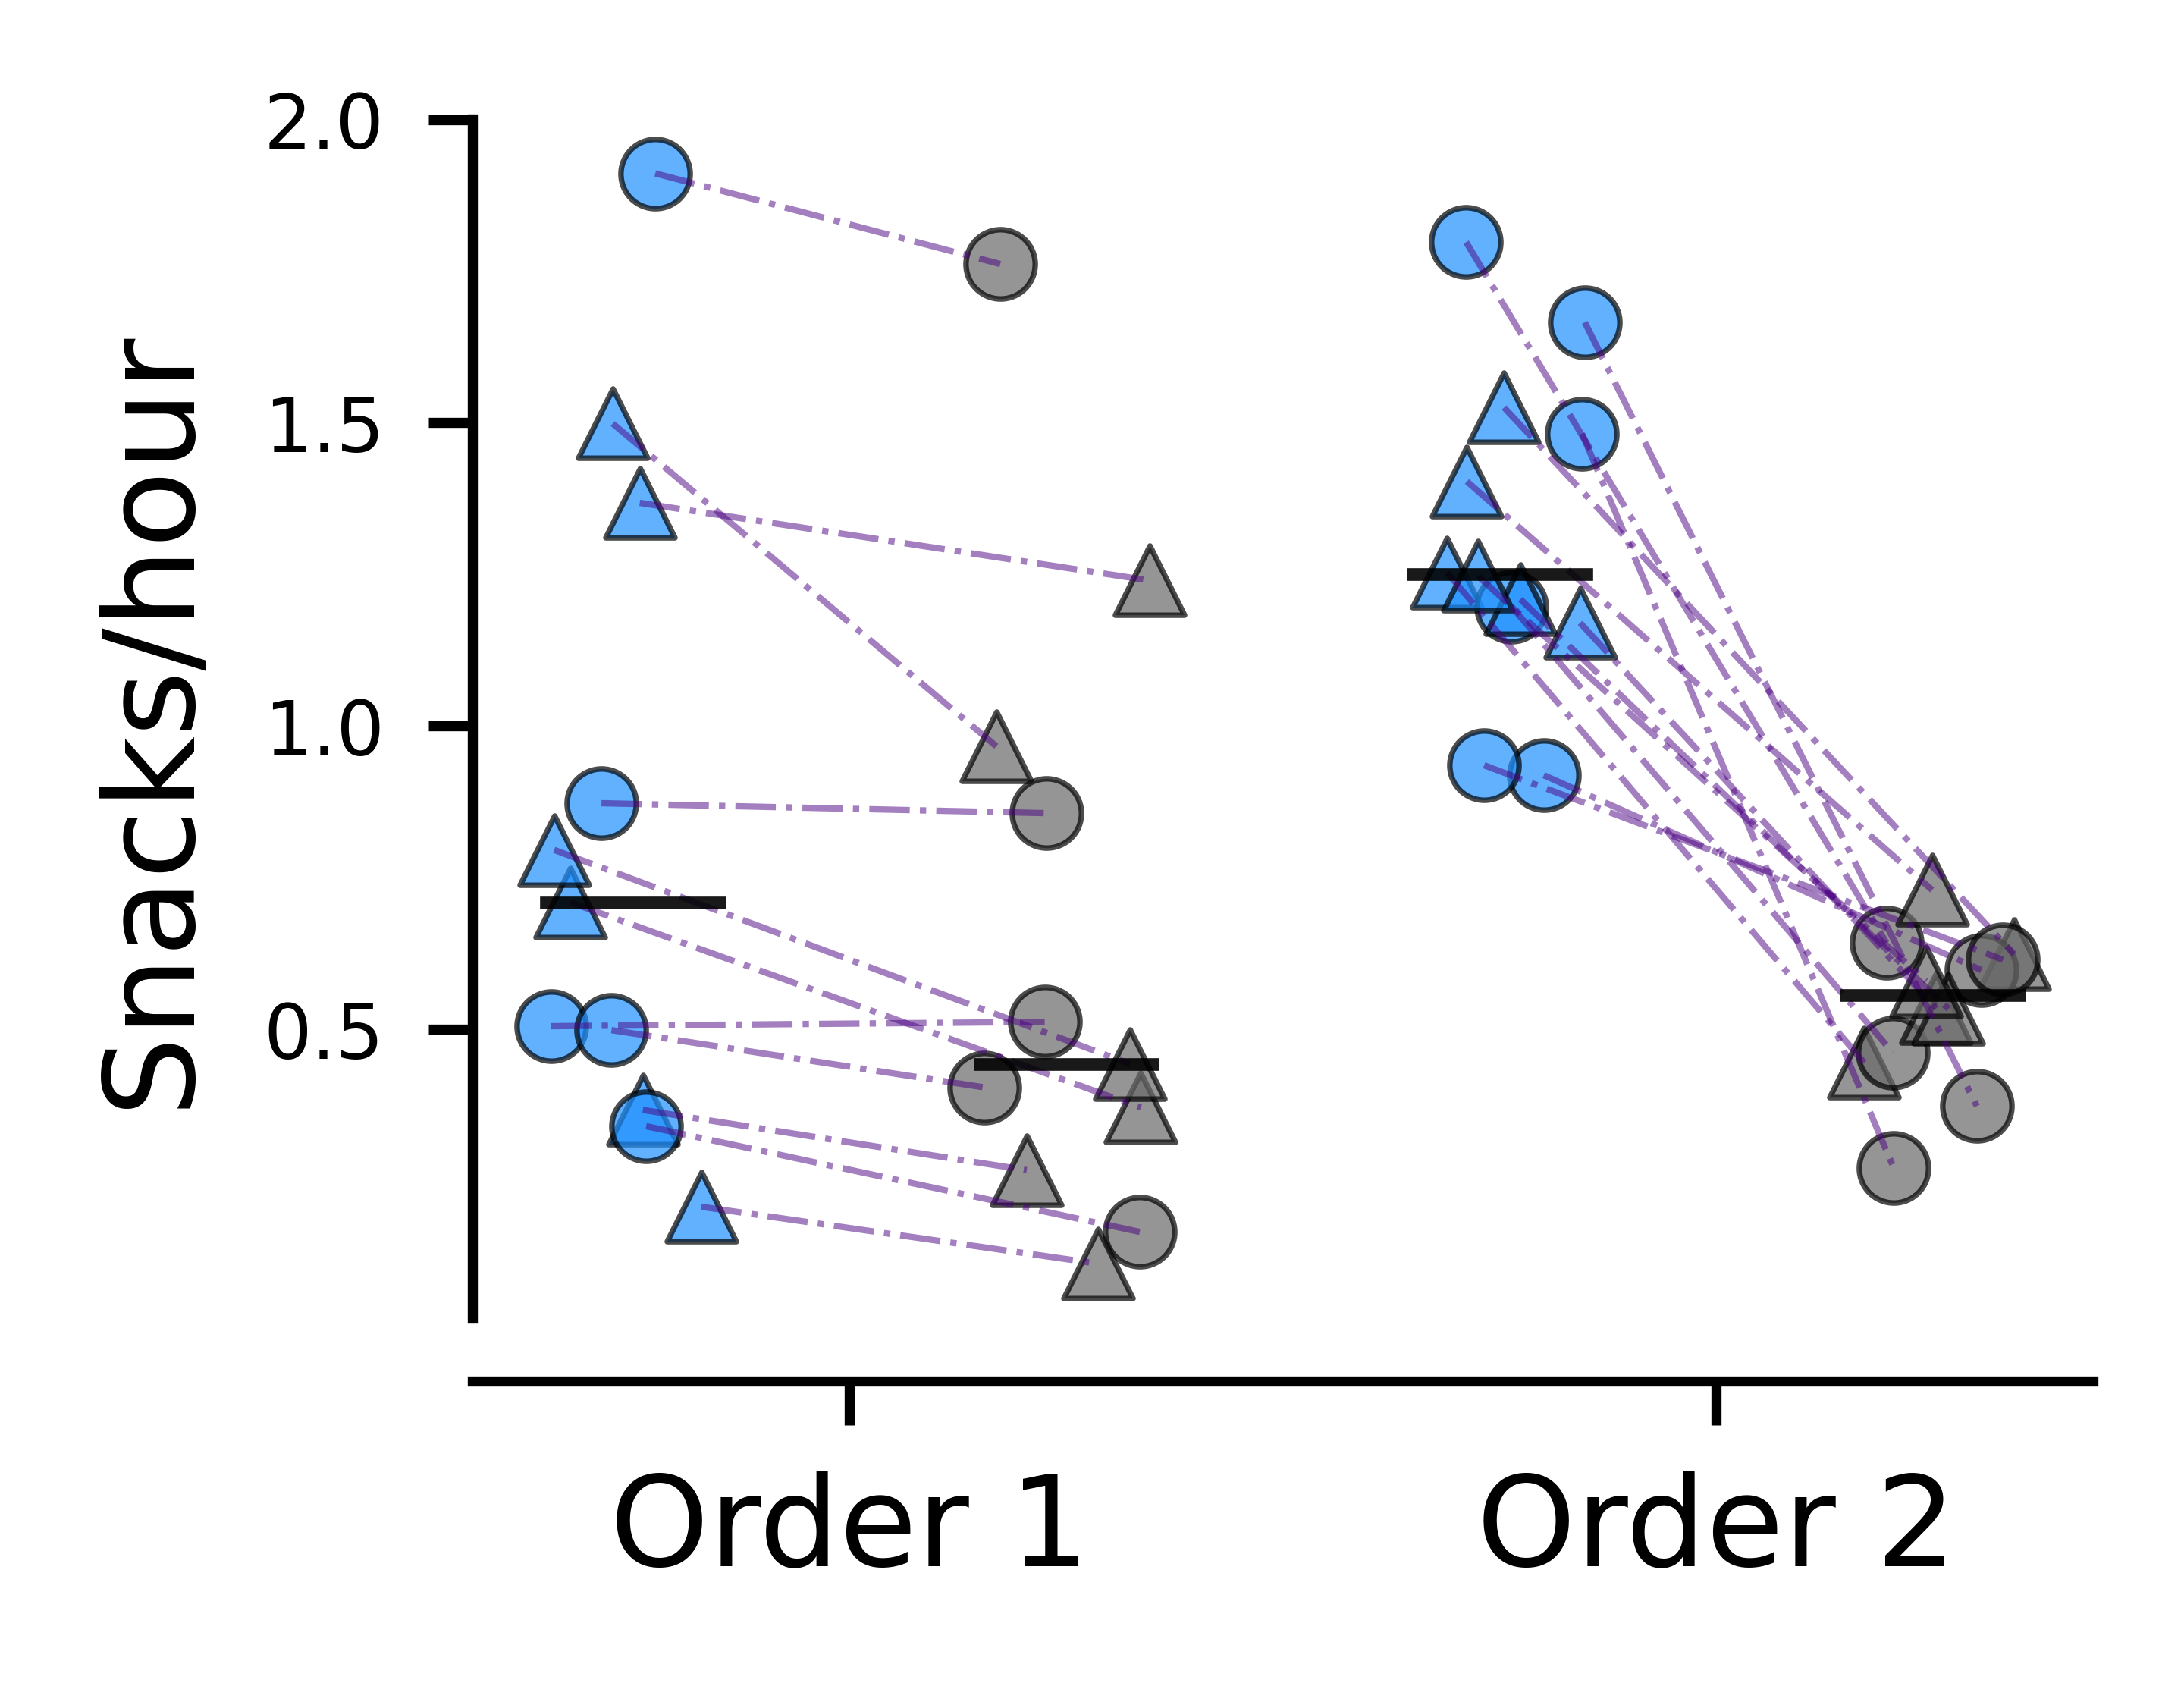

In [12]:
# Extract combined snack frequency data for PR and NR phases, separated by order
nrpr_snack_freq = get_data_fields(mice, ["pr_snack_frequency", "nr_snack_frequency"], {"order": 1})
prnr_snack_freq = get_data_fields(mice, ["pr_snack_frequency", "nr_snack_frequency"], {"order": 2})

# Prepare data for plotting
data = [nrpr_snack_freq[0], nrpr_snack_freq[1], prnr_snack_freq[0], prnr_snack_freq[1]]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
offset = {"PR": -0.05, "NR": 0.05}  # Offset for compact spacing
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Closer positions for minimal gap

# Create a figure and axis
fig, ax = plt.subplots(figsize=(2.5, 1.88), dpi=1200)
jitter_strength = 0.02

# Plot data points and connect pairs with lines
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = data[i * 2]   # PR data for Order 1 or Order 2
    nr_data = data[i * 2 + 1]  # NR data for Order 1 or Order 2

    for j in range(len(pr_data)):
        # Apply jitter to x-positions for PR and NR
        pr_x = group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength)
        nr_x = group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength)
        
        # Draw line connecting PR and NR for each individual mouse
        ax.plot([pr_x, nr_x], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot individual data points with gender-specific markers
        marker = '^' if j % 2 == 0 else 'o'  # Triangles for females, circles for males
        sns.scatterplot(x=[pr_x], y=[pr_data[j]], color=colors["PR"], marker=marker, s=30, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x], y=[nr_data[j]], color=colors["NR"], marker=marker, s=30, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = data[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='k', linewidth=1, alpha=0.9)

# # Customize legend with no frame and no title
# custom_lines = [
#     Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
#     Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
# ]
# plt.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(1, 0.9), frameon=False, fontsize=4)

# # Add combined colored text for PR and NR next to the legend
# plt.text(1.05, 0.65, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=4)
# plt.text(1.05, 0.70, '20% casein', color='dimgray', transform=ax.transAxes, fontsize=4)

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]], ["Order 1", "Order 2"], fontsize=10)
plt.yticks(fontsize=6)
plt.xlabel("")
plt.ylabel("Snacks/hour", fontsize=10)
sns.despine()
plt.tight_layout()
offset = 5  # points
ax.spines['bottom'].set_position(('outward', offset))
plt.show()

# Save the figure if needed
fig.savefig("../plots/Fig.6C.pdf")


In [13]:

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.lines import Line2D



nrpr_male_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 1, "sex": "M"})
prnr_male_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 2, "sex": "M"})
nrpr_female_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 1, "sex": "F"})
prnr_female_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 2, "sex": "F"})

# Prepare lists in the order: [O1-PR, O1-NR, O2-PR, O2-NR]
male_data = [
    np.asarray(nrpr_male_feast_freq[0]), np.asarray(nrpr_male_feast_freq[1]),
    np.asarray(prnr_male_feast_freq[0]), np.asarray(prnr_male_feast_freq[1]),
]
female_data = [
    np.asarray(nrpr_female_feast_freq[0]), np.asarray(nrpr_female_feast_freq[1]),
    np.asarray(prnr_female_feast_freq[0]), np.asarray(prnr_female_feast_freq[1]),
]

group_labels = ["Order 1", "Order 2"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
markers = {"M": "o", "F": "^"}

# Tight grouping with a small PR/NR offset
group_positions = {"Order 1": 0.00, "Order 2": 0.25}
offset = {"PR": -0.05, "NR": 0.05}
jitter_strength = 0.015  # horizontal jitter for dot spread

# Output folder
outdir = "../plots/feasts_by_sex"
os.makedirs(outdir, exist_ok=True)

# 2) Utility: compute shared y-lims across both sexes for comparability
def compute_ylim(male_data, female_data, pad=0.2):
    # Flatten all arrays across both sexes
    all_arrays = male_data + female_data
    # Handle empty data safely
    valid_vals = np.concatenate([a[np.isfinite(a)] for a in all_arrays if a is not None and len(a) > 0]) \
                 if any(len(a) > 0 for a in all_arrays) else np.array([0.0])
    y_min = float(np.nanmin(valid_vals)) if valid_vals.size else 0.0
    y_max = float(np.nanmax(valid_vals)) if valid_vals.size else 1.0
    if y_min == y_max:  # edge case: all equal
        y_min -= 0.5
        y_max += 0.5
    # Add a small padding
    y_range = y_max - y_min
    return (y_min - pad * y_range, y_max + pad * y_range)

shared_ylim = compute_ylim(male_data, female_data, pad=0.15)


def plot_feasts_by_sex(data_list, sex_label, filename_pdf,
                       figsize=(2.5, 1.88), dpi=220, use_shared_ylim=None):
    """
    data_list: [O1-PR, O1-NR, O2-PR, O2-NR]
    sex_label: 'M' or 'F'
    """
    # Reproducible jitter
    rng = np.random.default_rng(42 if sex_label == 'M' else 43)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, constrained_layout=True)

    # Loop orders
    for order_idx, order in enumerate(group_labels):
        pr_vals = data_list[order_idx * 2]
        nr_vals = data_list[order_idx * 2 + 1]
        n = len(pr_vals)

        # x positions with jitter
        pr_x = group_positions[order] + offset["PR"] + rng.uniform(-jitter_strength, jitter_strength, size=n)
        nr_x = group_positions[order] + offset["NR"] + rng.uniform(-jitter_strength, jitter_strength, size=n)

        # Connecting lines (paired)
        for i in range(n):
            if np.isfinite(pr_vals[i]) and np.isfinite(nr_vals[i]):
                ax.plot([pr_x[i], nr_x[i]], [pr_vals[i], nr_vals[i]],
                        color='indigo', linestyle='-.', linewidth=0.5, alpha=0.55, zorder=1)

        # Scatter PR & NR
        sns.scatterplot(x=pr_x, y=pr_vals, color=colors["PR"],
                        marker=markers[sex_label], s=30, alpha=0.8,
                        edgecolor="black", linewidth=0.4, ax=ax, zorder=2)
        sns.scatterplot(x=nr_x, y=nr_vals, color=colors["NR"],
                        marker=markers[sex_label], s=30, alpha=0.8,
                        edgecolor="black", linewidth=0.4, ax=ax, zorder=2)

        # Median ticks
        if np.isfinite(np.nanmedian(pr_vals)):
            m_pr = float(np.nanmedian(pr_vals))
            x_pr = group_positions[order] + offset["PR"]
            ax.plot([x_pr - 0.02, x_pr + 0.02], [m_pr, m_pr], color='black', linewidth=2, alpha=0.9, zorder=3)
        if np.isfinite(np.nanmedian(nr_vals)):
            m_nr = float(np.nanmedian(nr_vals))
            x_nr = group_positions[order] + offset["NR"]
            ax.plot([x_nr - 0.02, x_nr + 0.02], [m_nr, m_nr], color='black', linewidth=2, alpha=0.9, zorder=3)

    # Axes cosmetics
    ax.set_xticks([group_positions["Order 1"], group_positions["Order 2"]])
    ax.set_xticklabels(group_labels, fontsize=9)
    ax.set_xlabel("")
    
    ax.set_ylabel("Number of feasts", fontsize=10)
    ax.tick_params(axis='y', labelsize=10)

    # Nice x-limits to include jittered dots
    x_min = min(group_positions.values()) - 0.12
    x_max = max(group_positions.values()) + 0.12
    ax.set_xlim(x_min, x_max)

    # Shared y-limits for comparability (optional)
    if use_shared_ylim is not None:
        ax.set_ylim(*use_shared_ylim)

    # Clean spines
    sns.despine(ax=ax)
    ax.spines['bottom'].set_position(('outward', 5))

    # # Tiny colour key (PR/NR) — optional; remove if you don’t want it
    # ax.text(0.98, 0.96, "PR (5% casein)", color=colors["PR"],
    #         transform=ax.transAxes, ha='right', va='top', fontsize=7)
    # ax.text(0.98, 0.88, "NR (20% casein)", color='black',
    #         transform=ax.transAxes, ha='right', va='top', fontsize=7)

    # Title per sex (optional)
    ax.set_title("" if sex_label == 'M' else "", fontsize=10)

    # Save as vector PDF
    save_path = os.path.join(outdir, filename_pdf)
    fig.savefig(save_path, bbox_inches='tight', transparent=True)
    plt.close(fig)
    print(f"Saved: {save_path}")

# -----------------------------
# 4) Make & save both PDFs
# -----------------------------
plot_feasts_by_sex(male_data,   'M', filename_pdf="Fig.7A.pdf",   use_shared_ylim=shared_ylim)
plot_feasts_by_sex(female_data, 'F', filename_pdf="Fig.8A.pdf", use_shared_ylim=shared_ylim)




6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary
Saved: ../plots/feasts_by_sex\Fig.7A.pdf
Saved: ../plots/feasts_by_sex\Fig.8A.pdf


In [ ]:



# Extract Feast size data for PR and NR phases, separated by order and sex
nrpr_male_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 1, "sex": "M"})
prnr_male_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 2, "sex": "M"})
nrpr_female_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 1, "sex": "F"})
prnr_female_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 2, "sex": "F"})


# Prepare lists in the order: [O1-PR, O1-NR, O2-PR, O2-NR]
male_data = [
    np.asarray(nrpr_male_feast_size[0]), np.asarray(nrpr_male_feast_size[1]),
    np.asarray(prnr_male_feast_size[0]), np.asarray(prnr_male_feast_size[1]),
]
female_data = [
    np.asarray(nrpr_female_feast_size[0]), np.asarray(nrpr_female_feast_size[1]),
    np.asarray(prnr_female_feast_size[0]), np.asarray(prnr_female_feast_size[1]),
]

group_labels = ["Order 1", "Order 2"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
markers = {"M": "o", "F": "^"}

# Tight grouping with a small PR/NR offset
group_positions = {"Order 1": 0.00, "Order 2": 0.25}
offset = {"PR": -0.05, "NR": 0.05}
jitter_strength = 0.015  # horizontal jitter for dot spread

# Output folder
outdir = "../plots/feast_size_by_sex"
os.makedirs(outdir, exist_ok=True)

# 2) Utility: compute shared y-lims across both sexes for comparability
def compute_ylim(male_data, female_data, pad=0.2):
    # Flatten all arrays across both sexes
    all_arrays = male_data + female_data
    # Handle empty data safely
    valid_vals = np.concatenate([a[np.isfinite(a)] for a in all_arrays if a is not None and len(a) > 0]) \
                 if any(len(a) > 0 for a in all_arrays) else np.array([0.0])
    y_min = float(np.nanmin(valid_vals)) if valid_vals.size else 0.0
    y_max = float(np.nanmax(valid_vals)) if valid_vals.size else 1.0
    if y_min == y_max:  # edge case: all equal
        y_min -= 0.5
        y_max += 0.5
    # Add a small padding
    y_range = y_max - y_min
    return (y_min - pad * y_range, y_max + pad * y_range)

shared_ylim = compute_ylim(male_data, female_data, pad=0.15)


def plot_feasts_by_sex(data_list, sex_label, filename_pdf,
                       figsize=(2.5, 1.88), dpi=220, use_shared_ylim=None):
    """
    data_list: [O1-PR, O1-NR, O2-PR, O2-NR]
    sex_label: 'M' or 'F'
    """
    # Reproducible jitter
    rng = np.random.default_rng(42 if sex_label == 'M' else 43)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, constrained_layout=True)

    # Loop orders
    for order_idx, order in enumerate(group_labels):
        pr_vals = data_list[order_idx * 2]
        nr_vals = data_list[order_idx * 2 + 1]
        n = len(pr_vals)

        # x positions with jitter
        pr_x = group_positions[order] + offset["PR"] + rng.uniform(-jitter_strength, jitter_strength, size=n)
        nr_x = group_positions[order] + offset["NR"] + rng.uniform(-jitter_strength, jitter_strength, size=n)

        # Connecting lines (paired)
        for i in range(n):
            if np.isfinite(pr_vals[i]) and np.isfinite(nr_vals[i]):
                ax.plot([pr_x[i], nr_x[i]], [pr_vals[i], nr_vals[i]],
                        color='indigo', linestyle='-.', linewidth=0.5, alpha=0.55, zorder=1)

        # Scatter PR & NR
        sns.scatterplot(x=pr_x, y=pr_vals, color=colors["PR"],
                        marker=markers[sex_label], s=30, alpha=0.8,
                        edgecolor="black", linewidth=0.4, ax=ax, zorder=2)
        sns.scatterplot(x=nr_x, y=nr_vals, color=colors["NR"],
                        marker=markers[sex_label], s=30, alpha=0.8,
                        edgecolor="black", linewidth=0.4, ax=ax, zorder=2)

        # Median ticks
        if np.isfinite(np.nanmedian(pr_vals)):
            m_pr = float(np.nanmedian(pr_vals))
            x_pr = group_positions[order] + offset["PR"]
            ax.plot([x_pr - 0.02, x_pr + 0.02], [m_pr, m_pr], color='black', linewidth=2, alpha=0.9, zorder=3)
        if np.isfinite(np.nanmedian(nr_vals)):
            m_nr = float(np.nanmedian(nr_vals))
            x_nr = group_positions[order] + offset["NR"]
            ax.plot([x_nr - 0.02, x_nr + 0.02], [m_nr, m_nr], color='black', linewidth=2, alpha=0.9, zorder=3)

    # Axes cosmetics
    ax.set_xticks([group_positions["Order 1"], group_positions["Order 2"]])
    ax.set_xticklabels(group_labels, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("Pellets/feast", fontsize=10)
    ax.tick_params(axis='y', labelsize=10)

    # Nice x-limits to include jittered dots
    x_min = min(group_positions.values()) - 0.12
    x_max = max(group_positions.values()) + 0.12
    ax.set_xlim(x_min, x_max)

    # Shared y-limits for comparability (optional)
    if use_shared_ylim is not None:
        ax.set_ylim(*use_shared_ylim)

    # Clean spines
    sns.despine(ax=ax)
    ax.spines['bottom'].set_position(('outward', 5))

  
    # ax.text(0.98, 0.96, "PR (5% casein)", color=colors["PR"],
    #         transform=ax.transAxes, ha='right', va='top', fontsize=7)
    # ax.text(0.98, 0.88, "NR (20% casein)", color='black',
    #         transform=ax.transAxes, ha='right', va='top', fontsize=7)

    # Title per sex (optional)
    ax.set_title("" if sex_label == 'M' else "", fontsize=10)

    # Save as vector PDF
    save_path = os.path.join(outdir, filename_pdf)
    fig.savefig(save_path, bbox_inches='tight', transparent=True)
    plt.close(fig)
    print(f"Saved: {save_path}")


plot_feasts_by_sex(male_data,   'M', filename_pdf="Fig.7E.pdf",   use_shared_ylim=shared_ylim)
plot_feasts_by_sex(female_data, 'F', filename_pdf="Fig.8E.pdf", use_shared_ylim=shared_ylim)




6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary
Saved: ../plots/feast_size_by_sex\Fig.7E.pdf
Saved: ../plots/feast_size_by_sex\Fig.8E.pdf


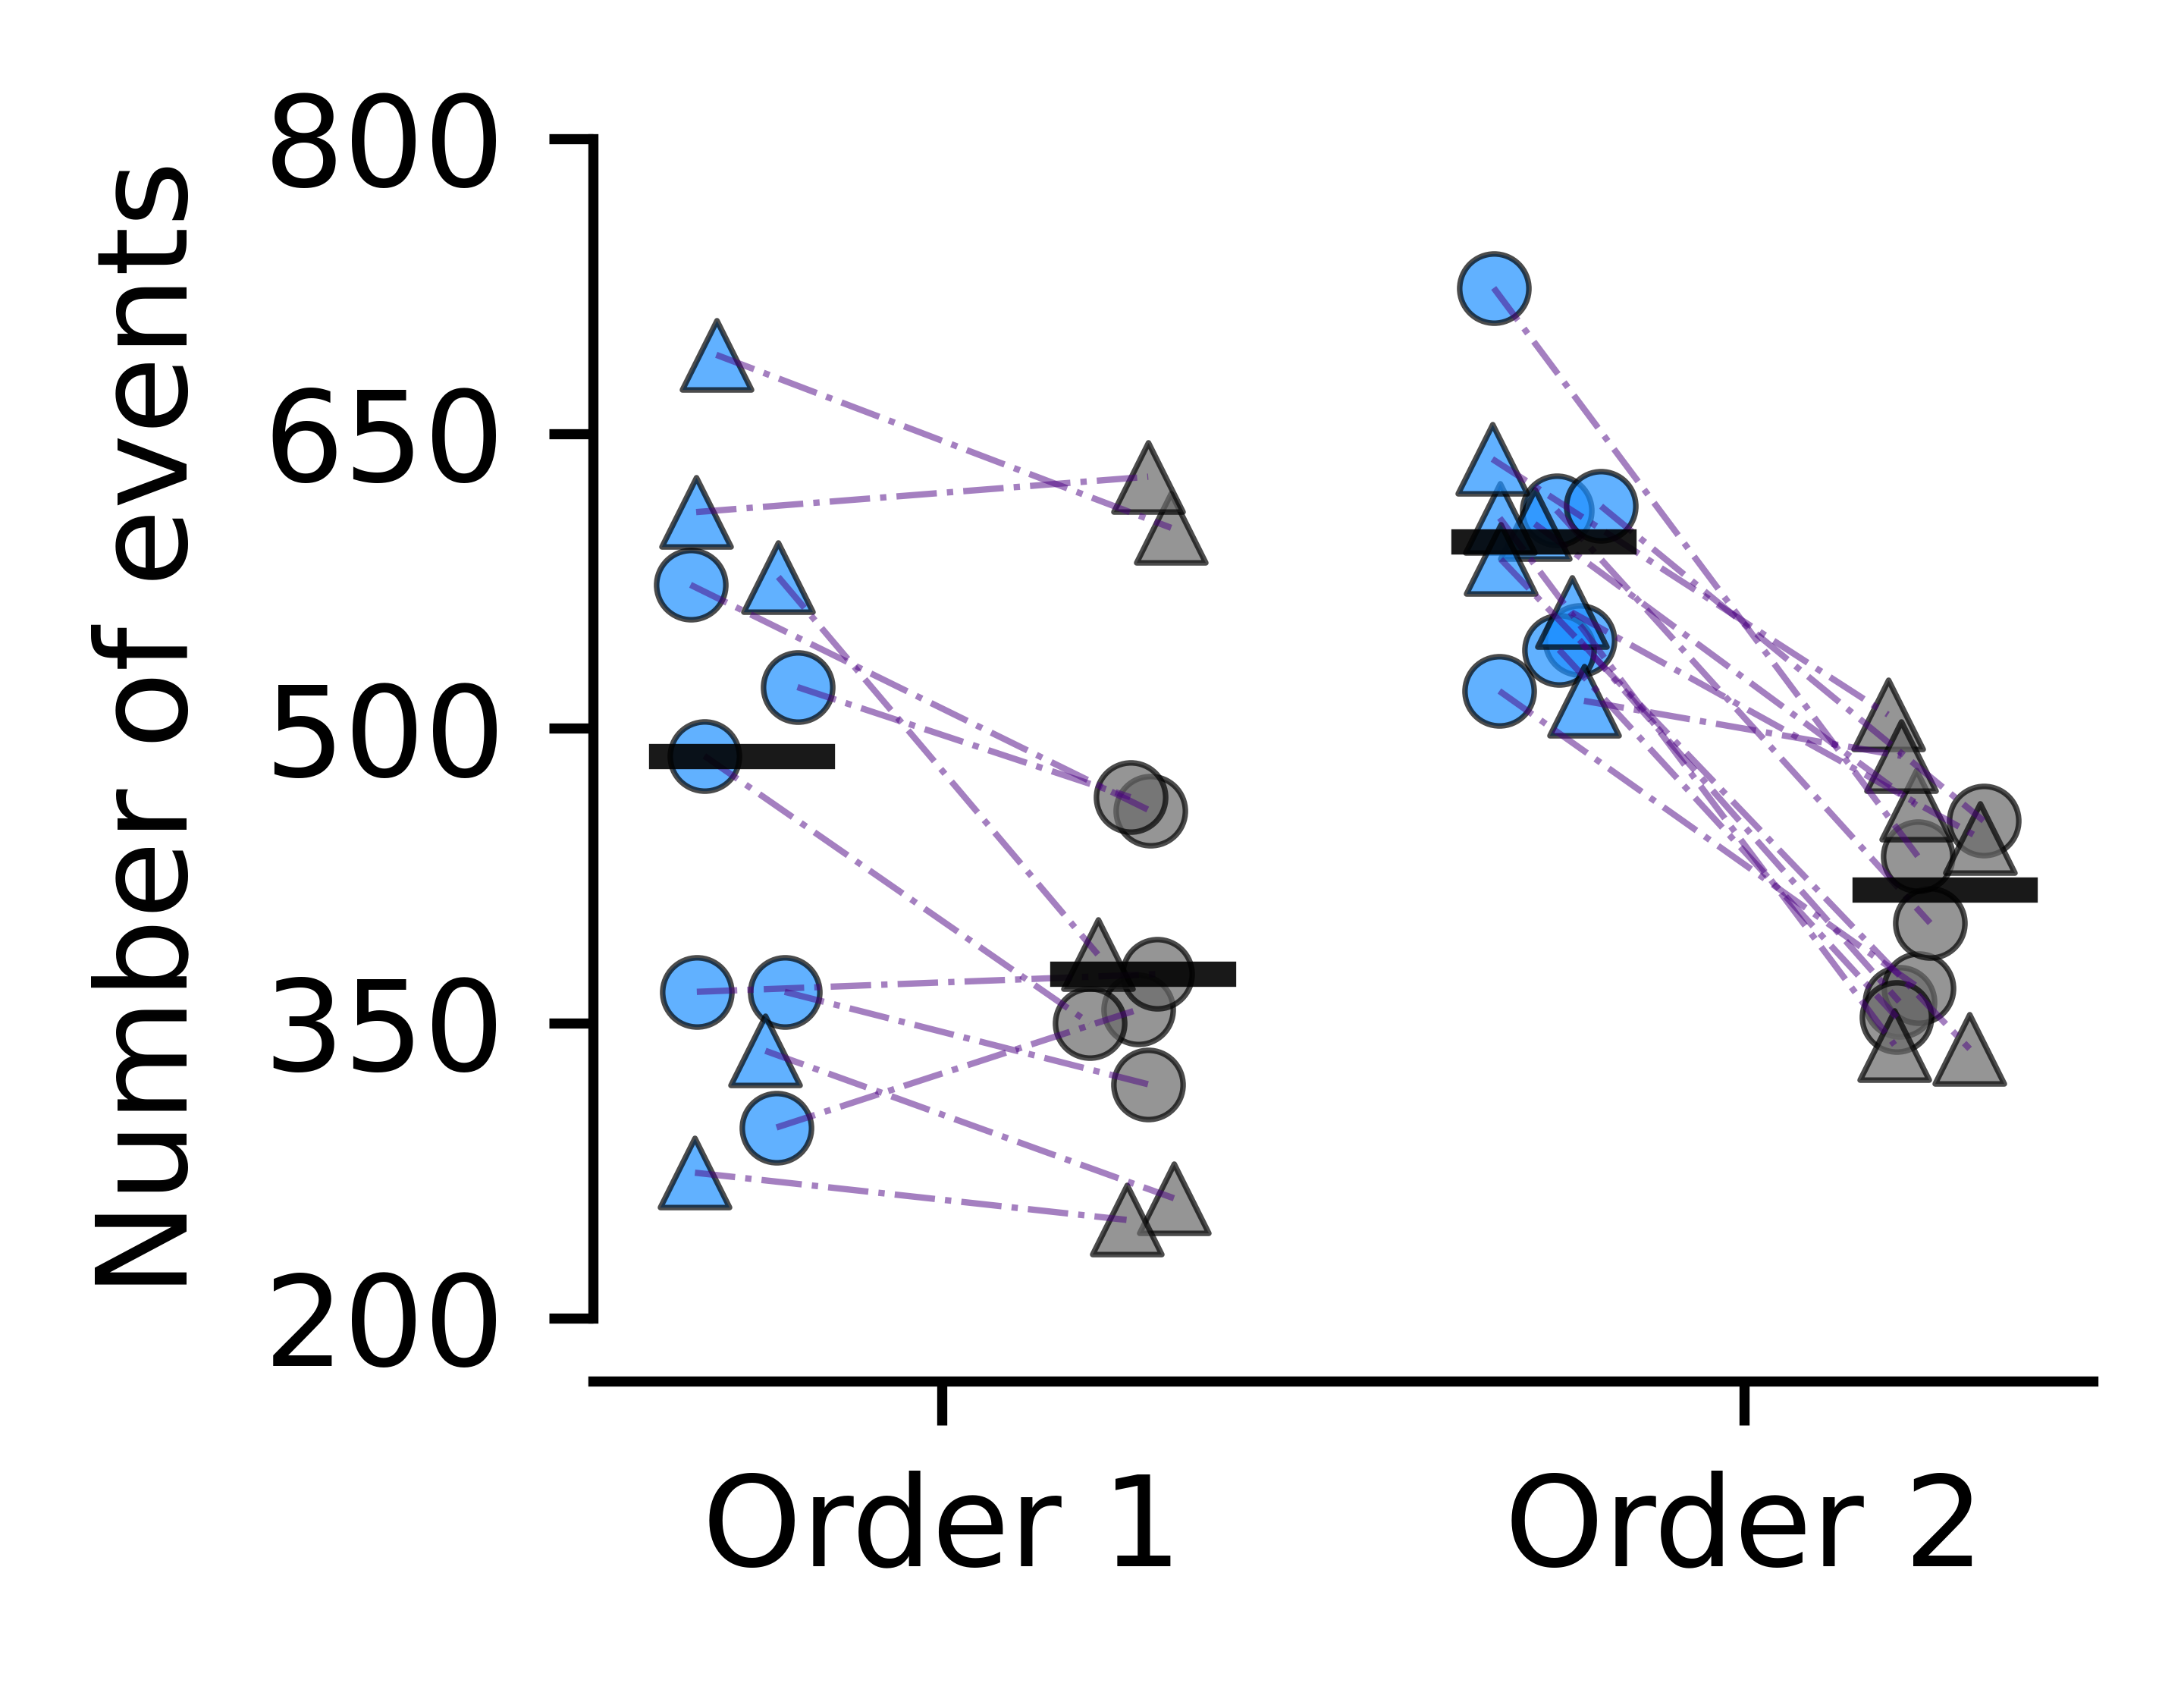

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Load the dataset
file_path = '../results/scatter_plots/SUM_OF_FEEDING_COMPONENTS/TOTAL_FEEDING_EVENTS.csv'
data = pd.read_csv(file_path)

# Separate data by order
nrpr_order1_data = data[data['Order'] == 1]
prnr_order2_data = data[data['Order'] == 2]

# Extract feeding data for plotting
nrpr_order1_pr = nrpr_order1_data['Total PR Parameters'].values
nrpr_order1_nr = nrpr_order1_data['Total NR Parameters'].values
prnr_order2_pr = prnr_order2_data['Total PR Parameters'].values
prnr_order2_nr = prnr_order2_data['Total NR Parameters'].values

# Prepare data for plotting
feeding_totals = [
    nrpr_order1_pr, nrpr_order1_nr,
    prnr_order2_pr, prnr_order2_nr
]
group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"]
colors = {"PR": "dodgerblue", "NR": "dimgray"}
offset = {"PR": -0.05, "NR": 0.05}  # Spacing between PR and NR
group_positions = {"Order 1": 0, "Order 2": 0.2}  # Adjusted for minimal gap
jitter_strength = 0.015  # Reduced jitter for clarity

# Create the figure
fig, ax = plt.subplots(figsize=(2.5, 1.88), dpi=1200)

# Plot data points with markers for sex and diet phase
for i, label in enumerate(["Order 1", "Order 2"]):
    pr_data = feeding_totals[i * 2]   # PR data for each order
    nr_data = feeding_totals[i * 2 + 1]  # NR data for each order
    sex_data_pr = nrpr_order1_data['Sex'].values if label == "Order 1" else prnr_order2_data['Sex'].values

    # Apply jitter to x-positions and assign markers based on sex
    pr_x = [group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in pr_data]
    nr_x = [group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in nr_data]

    # Draw line connecting PR and NR for each combined data point
    for j in range(len(pr_data)):
        ax.plot([pr_x[j], nr_x[j]], [pr_data[j], nr_data[j]], color='indigo', linestyle='-.', linewidth=0.5, alpha=0.5)

        # Plot individual data points with markers based on sex
        sex_marker = '^' if sex_data_pr[j] == 'F' else 'o'  # Triangle for females, circle for males
        sns.scatterplot(x=[pr_x[j]], y=[pr_data[j]], color=colors["PR"], marker=sex_marker, s=30, alpha=0.7, edgecolor="black")
        sns.scatterplot(x=[nr_x[j]], y=[nr_data[j]], color=colors["NR"], marker=sex_marker, s=30, alpha=0.7, edgecolor="black")

# Add median lines for each group and diet
for group, pos in group_positions.items():
    for diet, diet_color in colors.items():
        relevant_data = feeding_totals[group_labels.index(f"{group} ({diet})")]
        median_value = np.median(relevant_data)
        x_val = pos + offset[diet]
        ax.plot([x_val - 0.02, x_val + 0.02], [median_value, median_value], color='black', linewidth=2, alpha=0.9)

# # Customize legend with markers for male and female
# custom_lines = [
#     Line2D([0], [0], marker='^', color='black', linestyle='', markersize=4, label='Female', fillstyle='none'),
#     Line2D([0], [0], marker='o', color='black', linestyle='', markersize=4, label='Male', fillstyle='none')
# ]
# ax.legend(handles=custom_lines, loc="upper left", bbox_to_anchor=(0.8, 1), frameon=False, fontsize=4)

# # Add text labels for PR and NR phases
# ax.text(0.83, 0.75, '5% casein', color='dodgerblue', transform=ax.transAxes, fontsize=4)
# ax.text(0.83, 0.81, '20% casein', color='dimgray', transform=ax.transAxes, fontsize=4)

# Plot settings
plt.xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1", "Order 2"], fontsize=10)
plt.yticks(fontsize=6)

# Add more y-ticks
current_yticks = ax.get_yticks()
new_yticks = np.linspace(current_yticks[0], current_yticks[-1], len(current_yticks) + 1)
plt.yticks(new_yticks, fontsize=10)

plt.xlabel("")
plt.ylabel("Number of events", fontsize=10)
sns.despine()
plt.tight_layout()
offset = 5  # points
ax.spines['bottom'].set_position(('outward', offset))
plt.show()

fig.savefig("../plots/Fig.9A.pdf", bbox_inches='tight', dpi=1200)
